In [2]:
from pathlib import Path
from scipy import stats, signal
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel

from chronos import ChronosPipeline
import torch
import torch.nn as nn

def parse_parameters(file_path):
    """
    Читает файл parameters.txt и возвращает словарь с нужными параметрами
    """
    params = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                key = parts[0]
                value = ' '.join(parts[1:])  # на случай, если значение содержит пробелы
                params[key] = value
    # Извлекаем нужные параметры
    result = {}
    for param in ['PName', 'Msw', 'XUVInt', 'H2a', 'Helium']:
        result[param] = params.get(param)
    return result

def process_files_in_folder_with_params(root_folder):
    """
    Рекурсивно проходит по папке, читает параметры и файлы с данными
    Возвращает список словарей, где каждый словарь — это один файл
    """
    dataset = []
    root = Path(root_folder)
    for data_file_path in root.rglob('*[.txt,.dat]'):
        if data_file_path.name == 'parameters.txt':
            continue  # Пропускаем файл параметров

        # Ищем файл parameters.txt в той же папке
        param_file_path = data_file_path.parent / 'parameters.txt'

        if param_file_path.exists():
            params = parse_parameters(param_file_path)
            # print(f"Файл: {data_file_path}")
            # print(f"Параметры: {params}")
        else:
            # print(f"Файл parameters.txt не найден для {data_file_path}")
            params = {}

        # Читаем V и FullAbs из data файла
        try:
            V, FullAbs = np.loadtxt(data_file_path, usecols=(0, 1), unpack=True, skiprows=1)
            entry = {
                'V': V,
                'FullAbs': FullAbs,
                'PName': params.get('PName'),
                'Msw': params.get('Msw'),
                'XUVInt': params.get('XUVInt'),
                'H2a': params.get('H2a'),
                'Helium': params.get('Helium'),
                # 'File': str(data_file_path)  # можно убрать, если не нужно
            }
            dataset.append(entry)
        except Exception as e:
            print(f"Ошибка при загрузке данных из {data_file_path}: {e}")
        # print("-" * 50)

    return dataset


def compute_basic_stats(arr):
    return {
        # 'min': np.min(arr),
        # 'max': np.max(arr),
        # 'mean': np.mean(arr),
        # 'median': np.median(arr),
        # 'std': np.std(arr),
        # 'var': np.var(arr),
        'skew': stats.skew(arr),
        'kurt': stats.kurtosis(arr)
    }

def compute_peak_features(x, y):
    # global peak
    idx_max = np.argmax(y)
    peak_x = x[idx_max]
    peak_y = y[idx_max]
    # FWHM: find x positions where y >= half max
    half = peak_y / 2.0
    # interpolate to get better precision
    f = interp1d(x, y - half, kind='linear')
    try:
        roots = np.sort(np.unique(np.hstack((np.where(np.sign(y-half)==0)[0]))))
        # simpler approach: find approximate left/right crossing by index
        left_idx = np.where(y[:idx_max] <= half)[0]
        right_idx = np.where(y[idx_max:] <= half)[0]
        if left_idx.size>0:
            left = np.interp(half, y[left_idx[-1]:left_idx[-1]+2], x[left_idx[-1]:left_idx[-1]+2])
        else:
            left = x[0]
        if right_idx.size>0:
            rbase = idx_max + right_idx[0]
            right = np.interp(half, y[rbase:rbase+2], x[rbase:rbase+2]) if rbase+1 < len(x) else x[-1]
        else:
            right = x[-1]
        fwhm = right - left
    except Exception:
        # fallback discrete
        indices = np.where(y >= half)[0]
        if indices.size>0:
            fwhm = x[indices[-1]] - x[indices[0]]
        else:
            fwhm = np.nan
    return {
        'peak_x': float(peak_x),
        'peak_y': float(peak_y),
        'fwhm': float(fwhm)
    }


def extract_features_from_profile(x, y):
    feats = {}
    # feats.update({'len': len(y)})
    # feats.update({f'Q_{q}': float(np.percentile(y, q)) for q in [1,5,25,50,75,95,99]})
    feats.update(compute_basic_stats(y))
    feats.update(compute_peak_features(x, y))
    # fft_feats, spec = compute_spectral_features(y, ncoef=6)
    # feats.update(fft_feats)
    # feats.update(spec)
    # feats.update(compute_derivative_features(x, y))
    # feats.update(compute_autocorr_features(y, lags=[1,2,5]))
    # AUC
    # feats['auc'] = float(np.trapz(y, x))
    # # left/center/right areas relative to peak
    # idx_max = np.argmax(y)
    # left_area = float(np.trapz(y[:idx_max+1], x[:idx_max+1])) if idx_max>0 else 0.0
    # right_area = float(np.trapz(y[idx_max:], x[idx_max:])) if idx_max < len(y)-1 else 0.0
    # feats['left_area'] = left_area
    # feats['right_area'] = right_area
    # feats['center_area_ratio'] = (feats['auc'] - left_area - right_area) / feats['auc'] if feats['auc']>0 else 0.0
    return feats


def analyze_dataframe(df):
    """
    Принимает DataFrame с колонками V, FullAbs и параметрами.
    Возвращает новый DataFrame: один объект = один профиль со всеми признаками.
    """
    rows = []

    for idx, row in df.iterrows():
        x = np.array(row['V'])
        y = np.array(row['FullAbs'])

        # Извлекаем признаки профиля
        feats = extract_features_from_profile(x, y)

        # Добавляем исходные параметры
        feats["FullAbs"] = y
        feats['Msw'] = row.get('Msw')
        feats['XUVInt'] = row.get('XUVInt')
        feats['Planet'] = row.get('PName')
        feats['H2a'] = row.get('H2a')
        feats['Helium'] = row.get('Helium')

        # feats['Msw'] = np.log1p(feats['Msw'].values.astype(np.float32))
        # feats['XUVInt'] = feats['XUVInt'].values.astype(np.float32)
        # feats['Helium'] = feats['Helium'].values.astype(np.float32)

        rows.append(feats)

    return pd.DataFrame(rows)

/home/kirill/diploma/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# dataset = process_files_in_folder_with_params("/home/kirill/diploma/new_dataset_V3")
import pandas as pd
dataset = pd.read_parquet('dataset.parquet')
dataset = analyze_dataframe(pd.DataFrame(dataset))
dataset['Msw'] = np.log1p(dataset['Msw'].values.astype(np.float32))
# dataset['Msw'] = dataset['Msw'].values.astype(np.float32)

dataset['XUVInt'] = dataset['XUVInt'].values.astype(np.float32)
dataset['Helium'] = dataset['Helium'].values.astype(np.float32)


In [4]:
df=dataset[dataset['fwhm'] == 2.0]
df

,skew,kurt,peak_x,peak_y,fwhm,FullAbs,Msw,XUVInt,Planet,H2a,Helium
41,1.217701,0.288484,0.1,0.023033,2.0,"[0.000472698, 0.000842511, 0.000967074, 0.0011...",30.403610,15.0,WASP69b,0,0.013022
58,1.159984,-0.011268,0.1,0.125586,2.0,"[0.00159533, 0.00282966, 0.00342357, 0.0045478...",28.547312,5.0,WASP107b,1,0.102200
70,1.204271,0.098624,0.0,0.146276,2.0,"[0.00685009, 0.00793905, 0.00920179, 0.0106423...",31.186369,15.0,WASP69b,0,0.074022
103,1.285254,0.246901,0.1,0.129905,2.0,"[0.00246982, 0.00447241, 0.00533872, 0.0067017...",31.562847,23.0,WASP69b,0,0.052022
112,1.207464,0.155740,-0.3,0.108336,2.0,"[0.00945476, 0.0107321, 0.0121888, 0.0138142, ...",31.961754,43.0,WASP69b,1,0.105022
122,1.198575,0.126885,-0.3,0.249042,2.0,"[0.0263391, 0.0285402, 0.0308431, 0.0332126, 0...",32.195370,19.0,WASP107b,0,0.042022
127,1.201219,0.176324,0.0,0.056087,2.0,"[0.00341978, 0.00376003, 0.00416995, 0.0046565...",31.562847,19.0,WASP52b,0,0.023022
245,1.240104,0.131958,0.0,0.044852,2.0,"[0.00157584, 0.00188374, 0.00224922, 0.0026739...",30.963226,49.0,WASP52b,1,0.020022
252,0.727318,-0.407821,-0.2,0.196732,2.0,"[0.0302291, 0.0364791, 0.0379462, 0.0740031, 0...",32.096928,11.0,WASP107b,0,0.261022
324,0.826479,-0.214515,-0.1,0.052666,2.0,"[0.0109886, 0.0113961, 0.0118828, 0.0124596, 0...",30.766516,3.0,WASP52b,0,0.172022


In [15]:
top5_values

array([2.])

In [20]:
x_data[0]

41     0.013022
58     0.102200
70     0.074022
103    0.052022
112    0.105022
122    0.042022
127    0.023022
245    0.020022
252    0.261022
324    0.172022
327    0.020022
349    0.227022
385    0.042022
386    0.032022
390    0.016022
393    0.011022
404    0.017022
418    0.052022
466    0.016022
475    0.279022
477    0.080022
478    0.279022
541    0.052022
552    0.015022
569    0.040220
591    0.014022
Name: Helium, dtype: float32

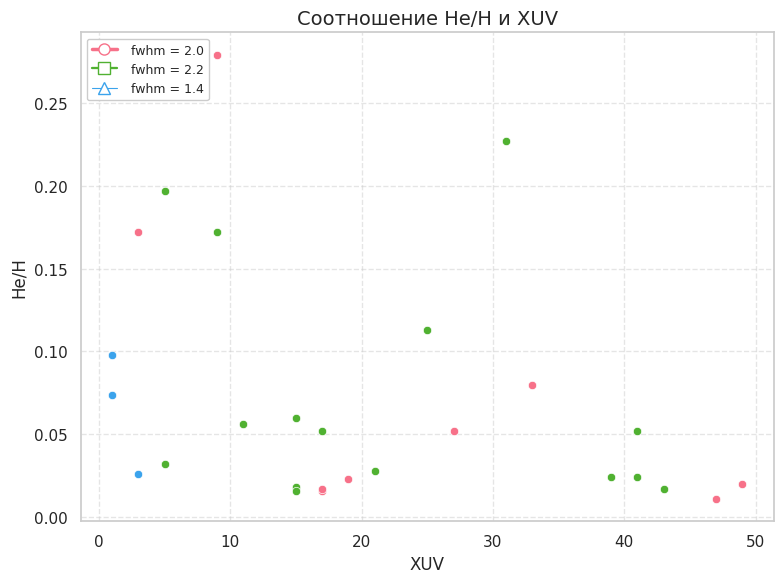

In [8]:
unique, counts = np.unique(dataset['fwhm'], return_counts=True)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Сортируем по убыванию частоты
sorted_idx = np.argsort(counts)[::-1]  # индексы от большего к меньшему

# Берём топ-5
top5_values = unique[sorted_idx[:3]]
x_data, y_data, param_names = [], [], []
for fwhm_value in top5_values:
    df=dataset[(dataset['fwhm'] == fwhm_value) & (dataset['Planet']=="WASP52b")]
    

    # x = np.linspace(-5, 5, 101)  # общий X (замените на ваши реальные x, если они разные)
    y = df['XUVInt']    # ваши данные
    x = df['Helium']
    x_data.append(x)
    y_data.append(y)
    param_names.append(f" fwhm = {fwhm_value}")
    

# ============================================================
# 2. НАСТРОЙКИ
# ============================================================
num_curves = len(x_data)
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*'][:num_curves]
linewidths = np.linspace(2.5, 0.8, num_curves)
colors = sns.color_palette("husl", num_curves)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# ============================================================
# 3. РИСУЕМ ГРАФИКИ
# ============================================================
legend_elements = []  # для сбора объектов легенды

for i in range(num_curves):
    x = x_data[i]
    y = y_data[i]
    marker = markers[i%len(markers)]
    lw = linewidths[i%len(linewidths)]
    color = colors[i%len(colors)]
    # Основная линия
    
    sns.scatterplot(x=y, y=x, color=color)
    
    # Маркеры с шагом
    step = 15
    indices = np.arange(0, len(x), step)
    
    
    # Добавляем элемент в легенду (линия + маркер)
    legend_elements.append(
        Line2D([0], [0], marker=marker, color=color, linewidth=lw,
               linestyle='-', markersize=8, markerfacecolor='white',
               label=param_names[i])
    )

# plt.plot(x_query, y_const_ext, color="blue")
# legend_elements.append(
#         Line2D([0], [0], color='blue',
#                linestyle='-', markersize=8,
#                label="Hat-P-32b (Czesla et al 2021)")
#     )
# ============================================================
# 4. ЛЕГЕНДА И ОФОРМЛЕНИЕ
# ============================================================
plt.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=1)

plt.xlabel("XUV", fontsize=12)
plt.ylabel("He/H", fontsize=12)
plt.title("Соотношение He/H и XUV", fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [14]:
param_names

[' fwhm = 2.0']

<Axes: xlabel='Helium', ylabel='Density'>

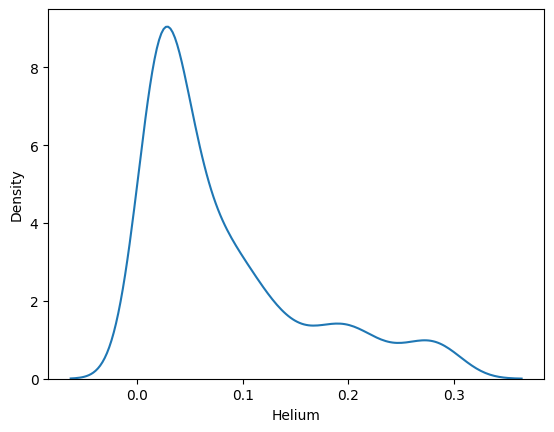

In [10]:
import seaborn as sns

sns.kdeplot(dataset['Helium'])

In [17]:
need_dataset = dataset[dataset["Helium"]>0.19][dataset["Helium"] <0.25]



/tmp/ipykernel_3543552/4072840846.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  need_dataset = dataset[dataset["Helium"]>0.19][dataset["Helium"] <0.25]


In [36]:
import pandas as pd

def read_txt_to_dataframe_v2(file_path, column_names=None):
    """
    Альтернативная версия с использованием read_csv и регулярного выражения
    """
    
    if column_names is None:
        column_names = ['VV', 'FullAbs', 'CI']
    elif len(column_names) != 3:
        raise ValueError("Должно быть ровно 3 имени столбцов")
    
    try:
        # Используем регулярное выражение для разделителя: 
        # пробел или табуляция, один или более раз
        df = pd.read_csv(
            file_path,
            sep=r'[ \t]+',  # регулярное выражение для пробелов и табуляций
            header=None,
            names=column_names,
            engine='python',  # python engine поддерживает regex разделители
            encoding='utf-8',
            skip_blank_lines=True
        )
        
        # Очистка строковых значений
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].str.strip()
        
        print(f"Файл успешно прочитан")
        print(f"Размер DataFrame: {df.shape}")
        
        return df
        
    except Exception as e:
        raise Exception(f"Ошибка при чтении файла: {e}")
    

df_Wasp52 = read_txt_to_dataframe_v2("hatp32b.txt")
# Удаляем строки с NaN (если были ошибки преобразования)
df_Wasp52_clean = df_Wasp52.dropna()

df_Wasp52_clean["VV"] = (
    df_Wasp52_clean["VV"]
    .astype(str)                      # гарантируем строковый тип
    .str.replace(',', '.')            # заменяем запятые на точки
    .str.replace(' ', '')             # удаляем пробелы если есть
)
df_Wasp52_clean["FullAbs"] = (
    df_Wasp52_clean["FullAbs"]
    .astype(str)                      # гарантируем строковый тип
    .str.replace(',', '.')            # заменяем запятые на точки
    .str.replace(' ', '')             # удаляем пробелы если есть
)
# Теперь можно преобразовывать в numpy float32
VV = df_Wasp52_clean["VV"].to_numpy(np.float32)
X = df_Wasp52_clean["FullAbs"].to_numpy(np.float32)
VV /= 10
X /= 100
# import seaborn as sns
# plt.figure(figsize=(10, 6))

# sns.lineplot(x=VV, y=X, label='Wasp-52b', color='blue', linewidth=2)
# # sns.lineplot(x=range(len(val_losses)), y=val_losses, label='val', color='red', linewidth=2)

# plt.title('Профиль поглощения Wasp52b)')
# plt.xlabel('V')
# plt.ylabel('abs')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


Файл успешно прочитан
Размер DataFrame: (41, 3)


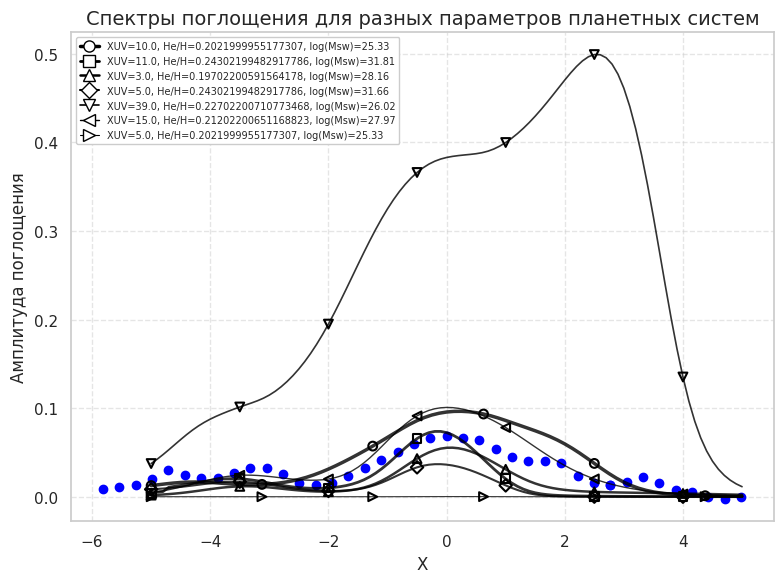

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ============================================================
# 1. ВАШИ ДАННЫЕ (замените на реальные)
# ============================================================
# Предполагается, что df уже загружен и содержит нужные колонки

x_data = []
y_data = []

for j in list(need_dataset.index):
    # x = np.linspace(-5, 5, 101)  # общий X (замените на ваши реальные x, если они разные)
    y = need_dataset["FullAbs"][j]    # ваши данные
    x = np.linspace(-5,5,len(y))
    x_data.append(x)
    y_data.append(y)

param_names = [
    f"XUV={need_dataset['XUVInt'][i]}, He/H={need_dataset['Helium'][i]}, log(Msw)={need_dataset['Msw'][i]:.2f}"
    for i in list(need_dataset.index)
]

# ============================================================
# 2. НАСТРОЙКИ
# ============================================================
markers = ['o', 's', '^', 'D', 'v', '<', '>']
linewidths = [2.5, 2.0, 1.8, 1.5, 1.2, 1.0, 0.8]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# ============================================================
# 3. РИСУЕМ ГРАФИКИ
# ============================================================
legend_elements = []  # для сбора объектов легенды

for i in range(7):
    x = x_data[i]
    y = y_data[i]
    marker = markers[i%len(markers)]
    lw = linewidths[i%len(linewidths)]
    
    # Основная линия
    try:
        plt.plot(x, y, color='black', linewidth=lw, alpha=0.8)
    except Exception as e:
        continue
    # Маркеры с шагом
    step = 15
    indices = np.arange(0, len(x), step)
    plt.scatter(x[indices], y[indices], marker=marker, s=40,
                facecolors='none', edgecolors='black', linewidths=1.5, zorder=5)
    
    # Добавляем элемент в легенду (линия + маркер)
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='black', linewidth=lw,
               linestyle='-', markersize=8, markerfacecolor='white',
               label=param_names[i])
    )

plt.scatter(VV, X, color="blue")
# ============================================================
# 4. ЛЕГЕНДА И ОФОРМЛЕНИЕ
# ============================================================
plt.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=1)

plt.xlabel("X", fontsize=12)
plt.ylabel("Амплитуда поглощения", fontsize=12)
plt.title("Спектры поглощения для разных параметров планетных систем", fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
import seaborn as sns

x_data

[array([-5.        , -4.75609756, -4.51219512, -4.26829268, -4.02439024,
        -3.7804878 , -3.53658537, -3.29268293, -3.04878049, -2.80487805,
        -2.56097561, -2.31707317, -2.07317073, -1.82926829, -1.58536585,
        -1.34146341, -1.09756098, -0.85365854, -0.6097561 , -0.36585366,
        -0.12195122,  0.12195122,  0.36585366,  0.6097561 ,  0.85365854,
         1.09756098,  1.34146341,  1.58536585,  1.82926829,  2.07317073,
         2.31707317,  2.56097561,  2.80487805,  3.04878049,  3.29268293,
         3.53658537,  3.7804878 ,  4.02439024,  4.26829268,  4.51219512,
         4.75609756,  5.        ]),
 array([-5.        , -4.75609756, -4.51219512, -4.26829268, -4.02439024,
        -3.7804878 , -3.53658537, -3.29268293, -3.04878049, -2.80487805,
        -2.56097561, -2.31707317, -2.07317073, -1.82926829, -1.58536585,
        -1.34146341, -1.09756098, -0.85365854, -0.6097561 , -0.36585366,
        -0.12195122,  0.12195122,  0.36585366,  0.6097561 ,  0.85365854,
         1.0975

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

def mean_absolute_percentage_error(y_true, y_pred, epsilon=1e-8):
    """
    Рассчитывает MAPE (Mean Absolute Percentage Error) в процентах.
    epsilon добавляется для защиты от деления на ноль.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Защита от нулевых значений в y_true
    mask = np.abs(y_true) < epsilon
    y_true = np.where(mask, epsilon, y_true)
    
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

feature_names = ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm']
target_names = ['XUVInt', 'Helium', 'Msw']

X = dataset[feature_names].values
y_all = dataset[target_names].values  # матрица [n_samples, 4]

# ============================================================
# 3. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_all, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} элементов")
print(f"Тестовая выборка: {X_test.shape[0]} элементов")
print("=" * 50)

# ============================================================
# 4. ОБУЧЕНИЕ XGBOOST ДЛЯ КАЖДОЙ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# ============================================================
# Быстрые параметры для XGBoost (хорошо работают "из коробки")
xgb_params = {
    'n_estimators': 1000,
    'max_depth': 16,
    'learning_rate': 0.01,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbosity': 0  # отключаем вывод логов
}

results = []

for i, target_name in enumerate(target_names):
    print(f"\nОбработка целевой переменной: {target_name}")
    print("-" * 30)
    
    # Обучаем модель
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train[:, i])
    
    # Предсказания
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Метрики на тестовой выборке
    mae = mean_absolute_error(y_test[:, i], y_pred_test)
    mse = mean_squared_error(y_test[:, i], y_pred_test)
    r2 = r2_score(y_test[:, i], y_pred_test)
    mape = mean_absolute_percentage_error(y_test[:,i], y_pred_test)
    # Сохраняем результаты
    results.append({
        'target': target_name,
        'MAE': mae,
        'MSE': mse,
        'R2': r2,
        'mape':mape,
        'model': model
    })
    
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R2:  {r2:.4f}")
    print(f"  MAPE: {mape:.4f}")

# ============================================================
# 5. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# ============================================================
print("\n" + "=" * 50)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 50)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ============================================================
# 6. ВАЖНОСТЬ ПРИЗНАКОВ (опционально)
# ============================================================
print("\n" + "=" * 50)
print("ВАЖНОСТЬ ПРИЗНАКОВ (для каждой целевой переменной)")
print("=" * 50)

for i, target_name in enumerate(target_names):
    model = results[i]['model']
    importance = model.feature_importances_
    print(f"\n{target_name}:")
    for feat, imp in zip(feature_names, importance):
        print(f"  {feat}: {imp:.4f}")

Обучающая выборка: 491 элементов
Тестовая выборка: 123 элементов

Обработка целевой переменной: XUVInt
------------------------------
  MAE: 8.3975
  MSE: 117.8760
  R2:  0.4610
  MAPE: 135.0074

Обработка целевой переменной: Helium
------------------------------
  MAE: 0.0405
  MSE: 0.0037
  R2:  0.3987
  MAPE: 89.7591

Обработка целевой переменной: Msw
------------------------------
  MAE: 0.8183
  MSE: 1.2153
  R2:  0.5761
  MAPE: 2.7926

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
target      MAE        MSE       R2       mape                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

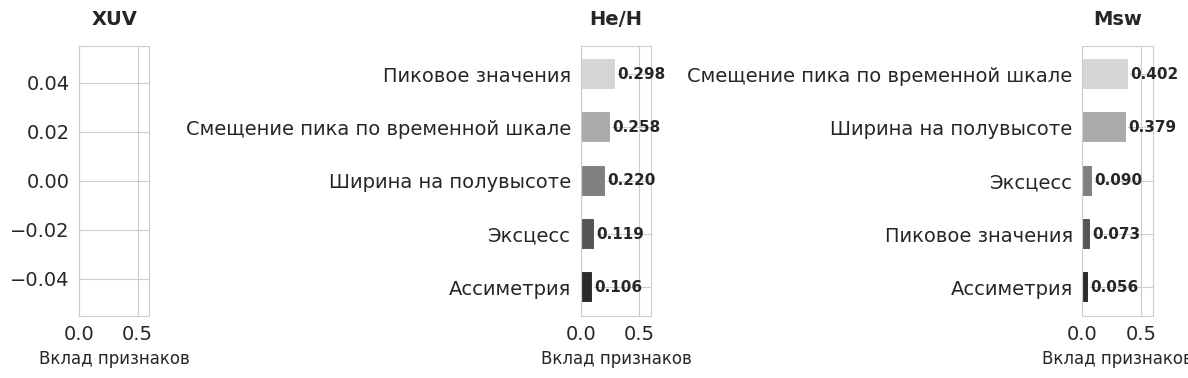

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



# Данные из вашего вывода
data = {
    'Feature': ['Ассиметрия', 'Эксцесс', 'Смещение пика по временной шкале', 'Пиковое значения', 'Ширина на полувысоте'] * 4,
    'Importance': [
        # XUVInt
        0.0842, 0.1437, 0.1659, 0.1422, 0.4639,
        # Helium
        0.1058, 0.1188, 0.2582, 0.2977, 0.2195,
        # Msw
        0.0559, 0.0903, 0.4019, 0.0727, 0.3792,
        # H2a
        0.1660, 0.1801, 0.2637, 0.1836, 0.2067
    ],
    'Target': ['XUV'] * 5 + ['Helium'] * 5 + ['Msw'] * 5 + ["H2a"] * 5
}

df = pd.DataFrame(data)

# Стиль
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 14, 'font.family': 'DejaVu Sans'})

# Создаём фигуру с тремя подграфиками
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Цветовая палитра
colors = sns.color_palette("grey", 5)

targets = ['XUVInt', 'Helium', 'Msw', "H2a"]
titles = ['XUV', 'He/H', 'Msw', "H2a"]

for ax, target, title in zip(axes, targets, titles):
    subset = df[df['Target'] == target].sort_values('Importance', ascending=True)
    
    bars = ax.barh(subset['Feature'], subset['Importance'], 
                   color=colors, edgecolor='white', linewidth=1.5, height=0.6)
    
    # Добавляем значения на столбцы
    for bar, val in zip(bars, subset['Importance']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Вклад признаков', fontsize=12)
    ax.set_xlim(0, 0.6)

plt.tight_layout()
plt.savefig('feature_importance_horizontal.png', dpi=150, bbox_inches='tight')
plt.show()

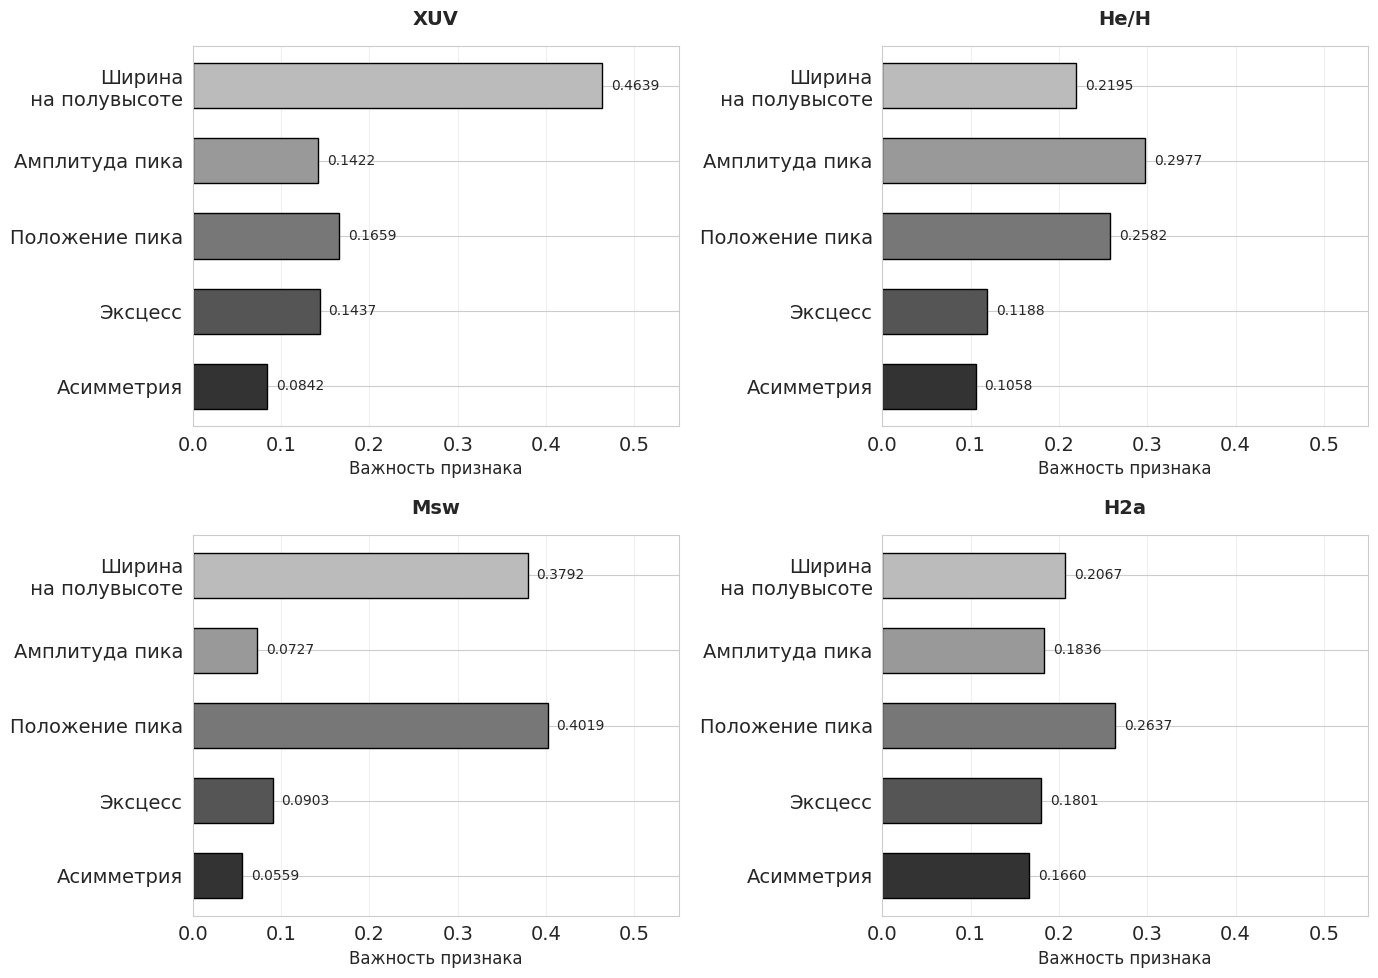

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Данные
data = {
    'Feature': ['Асимметрия', 'Эксцесс', 'Положение пика', 'Амплитуда пика', 'Ширина\n на полувысоте'] * 4,
    'Importance': [
        # XUVInt
        0.0842, 0.1437, 0.1659, 0.1422, 0.4639,
        # Helium
        0.1058, 0.1188, 0.2582, 0.2977, 0.2195,
        # Msw
        0.0559, 0.0903, 0.4019, 0.0727, 0.3792,
        # H2a
        0.1660, 0.1801, 0.2637, 0.1836, 0.2067
    ],
    'Target': ['XUVInt'] * 5 + ['Helium'] * 5 + ['Msw'] * 5 + ['H2a'] * 5
}

df = pd.DataFrame(data)

# Стиль
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 14, 'font.family': 'DejaVu Sans'})

# Фиксированный порядок признаков
feature_order = ['Асимметрия', 'Эксцесс', 'Положение пика', 'Амплитуда пика', 'Ширина\n на полувысоте']

# Цвета для признаков (фиксированные)
feature_colors = {
    'Асимметрия': '#333333',
    'Эксцесс': '#555555',
    'Положение пика': '#777777',
    'Амплитуда пика': '#999999',
    'Ширина\n на полувысоте': '#BBBBBB'
}

# Создаём фигуру с 4 подграфиками (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

targets = ['XUVInt', 'Helium', 'Msw', 'H2a']
titles = ['XUV', 'He/H', 'Msw', 'H2a']

for ax, target, title in zip(axes, targets, titles):
    subset = df[df['Target'] == target].copy()
    
    # Фиксируем порядок
    subset['Feature'] = pd.Categorical(subset['Feature'], categories=feature_order, ordered=True)
    subset = subset.sort_values('Feature')
    
    bar_colors = [feature_colors[f] for f in subset['Feature']]
    
    bars = ax.barh(subset['Feature'], subset['Importance'], 
                   color=bar_colors, edgecolor='black', linewidth=1, height=0.6)
    
    for bar, val in zip(bars, subset['Importance']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Важность признака', fontsize=12)
    ax.set_xlim(0, 0.55)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_horizontal_4targets.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
dataset

NameError: name 'dataset' is not defined

In [22]:
from sklearn.ensemble import RandomForestRegressor
rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'random_state': 42,
    'n_jobs': -1
}

# ============================================================
# 6. ФУНКЦИЯ ДЛЯ ОБУЧЕНИЯ И ОЦЕНКИ
# ============================================================
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, target_names):
    """Обучает модель для каждой целевой переменной и возвращает результаты"""
    results = []
    
    for i, target_name in enumerate(target_names):
        # Клонируем модель для каждой цели (или создаём новую)
        if model_name == 'XGBoost':
            model_i = xgb.XGBRegressor(**model)
        else:  # Random Forest
            model_i = RandomForestRegressor(**model)
        
        model_i.fit(X_train, y_train[:, i])
        y_pred_test = model_i.predict(X_test)
        
        mae = mean_absolute_error(y_test[:, i], y_pred_test)
        mse = mean_squared_error(y_test[:, i], y_pred_test)
        r2 = r2_score(y_test[:, i], y_pred_test)
        mape = mean_absolute_percentage_error(y_test[:, i], y_pred_test)
        
        results.append({
            'target': target_name,
            'MAE': mae,
            'MSE': mse,
            'R2': r2,
            'MAPE_%': mape
        })
    
    return results

# ============================================================
# 7. ОБУЧЕНИЕ XGBOOST
# ============================================================
print("\n" + "=" * 80)
print("XGBOOST РЕЗУЛЬТАТЫ")
print("=" * 80)

xgb_results = evaluate_model(xgb_params, 'XGBoost', X_train, y_train, X_test, y_test, target_names)
xgb_df = pd.DataFrame(xgb_results)
print(xgb_df.to_string(index=False, float_format='%.4f'))

# ============================================================
# 8. ОБУЧЕНИЕ RANDOM FOREST
# ============================================================
print("\n" + "=" * 80)
print("RANDOM FOREST РЕЗУЛЬТАТЫ")
print("=" * 80)

rf_results = evaluate_model(rf_params, 'RandomForest', X_train, y_train, X_test, y_test, target_names)
rf_df = pd.DataFrame(rf_results)
print(rf_df.to_string(index=False, float_format='%.4f'))

# ============================================================
# 9. СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ
# ============================================================
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ (R²)")
print("=" * 80)

comparison_df = pd.DataFrame({
    'target': target_names,
    'XGBoost_R2': [r['R2'] for r in xgb_results],
    'RandomForest_R2': [r['R2'] for r in rf_results],
    'XGBoost_MAPE': [r['MAPE_%'] for r in xgb_results],
    'RandomForest_MAPE': [r['MAPE_%'] for r in rf_results],
})
print(comparison_df.to_string(index=False, float_format='%.4f'))

# ============================================================
# 10. ВАЖНОСТЬ ПРИЗНАКОВ (для обеих моделей)
# ============================================================
print("\n" + "=" * 80)
print("ВАЖНОСТЬ ПРИЗНАКОВ")
print("=" * 80)

# Функция для получения важности признаков для Random Forest
def get_rf_importance(model, feature_names):
    return dict(zip(feature_names, model.feature_importances_))

# Переобучаем модели для получения важности признаков (для первого целевого)
print("\nRandom Forest важность признаков (для XUVInt):")
rf_model = RandomForestRegressor(**rf_params)
rf_model.fit(X_train, y_train[:, 0])
importance_rf = get_rf_importance(rf_model, feature_names)
for feat, imp in sorted(importance_rf.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {imp:.4f}")

print("\nXGBoost важность признаков (для XUVInt):")
xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_train, y_train[:, 0])
importance_xgb = dict(zip(feature_names, xgb_model.feature_importances_))
for feat, imp in sorted(importance_xgb.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {imp:.4f}")


XGBOOST РЕЗУЛЬТАТЫ
target    MAE      MSE     R2   MAPE_%
XUVInt 8.3975 117.8760 0.4610 135.0074
Helium 0.0405   0.0037 0.3987  89.7591
   Msw 0.8183   1.2153 0.5761   2.7926

RANDOM FOREST РЕЗУЛЬТАТЫ
target    MAE      MSE     R2   MAPE_%
XUVInt 8.9778 127.8163 0.4156 149.6615
Helium 0.0392   0.0035 0.4414  89.5434
   Msw 0.8617   1.2747 0.5554   2.9496

СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ (R²)
target  XGBoost_R2  RandomForest_R2  XGBoost_MAPE  RandomForest_MAPE
XUVInt      0.4610           0.4156      135.0074           149.6615
Helium      0.3987           0.4414       89.7591            89.5434
   Msw      0.5761           0.5554        2.7926             2.9496

ВАЖНОСТЬ ПРИЗНАКОВ

Random Forest важность признаков (для XUVInt):
  fwhm: 0.2590
  kurt: 0.2462
  peak_y: 0.2008
  skew: 0.1963
  peak_x: 0.0977

XGBoost важность признаков (для XUVInt):
  fwhm: 0.4639
  peak_x: 0.1659
  kurt: 0.1437
  peak_y: 0.1422
  skew: 0.0842


/home/kirill/diploma/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


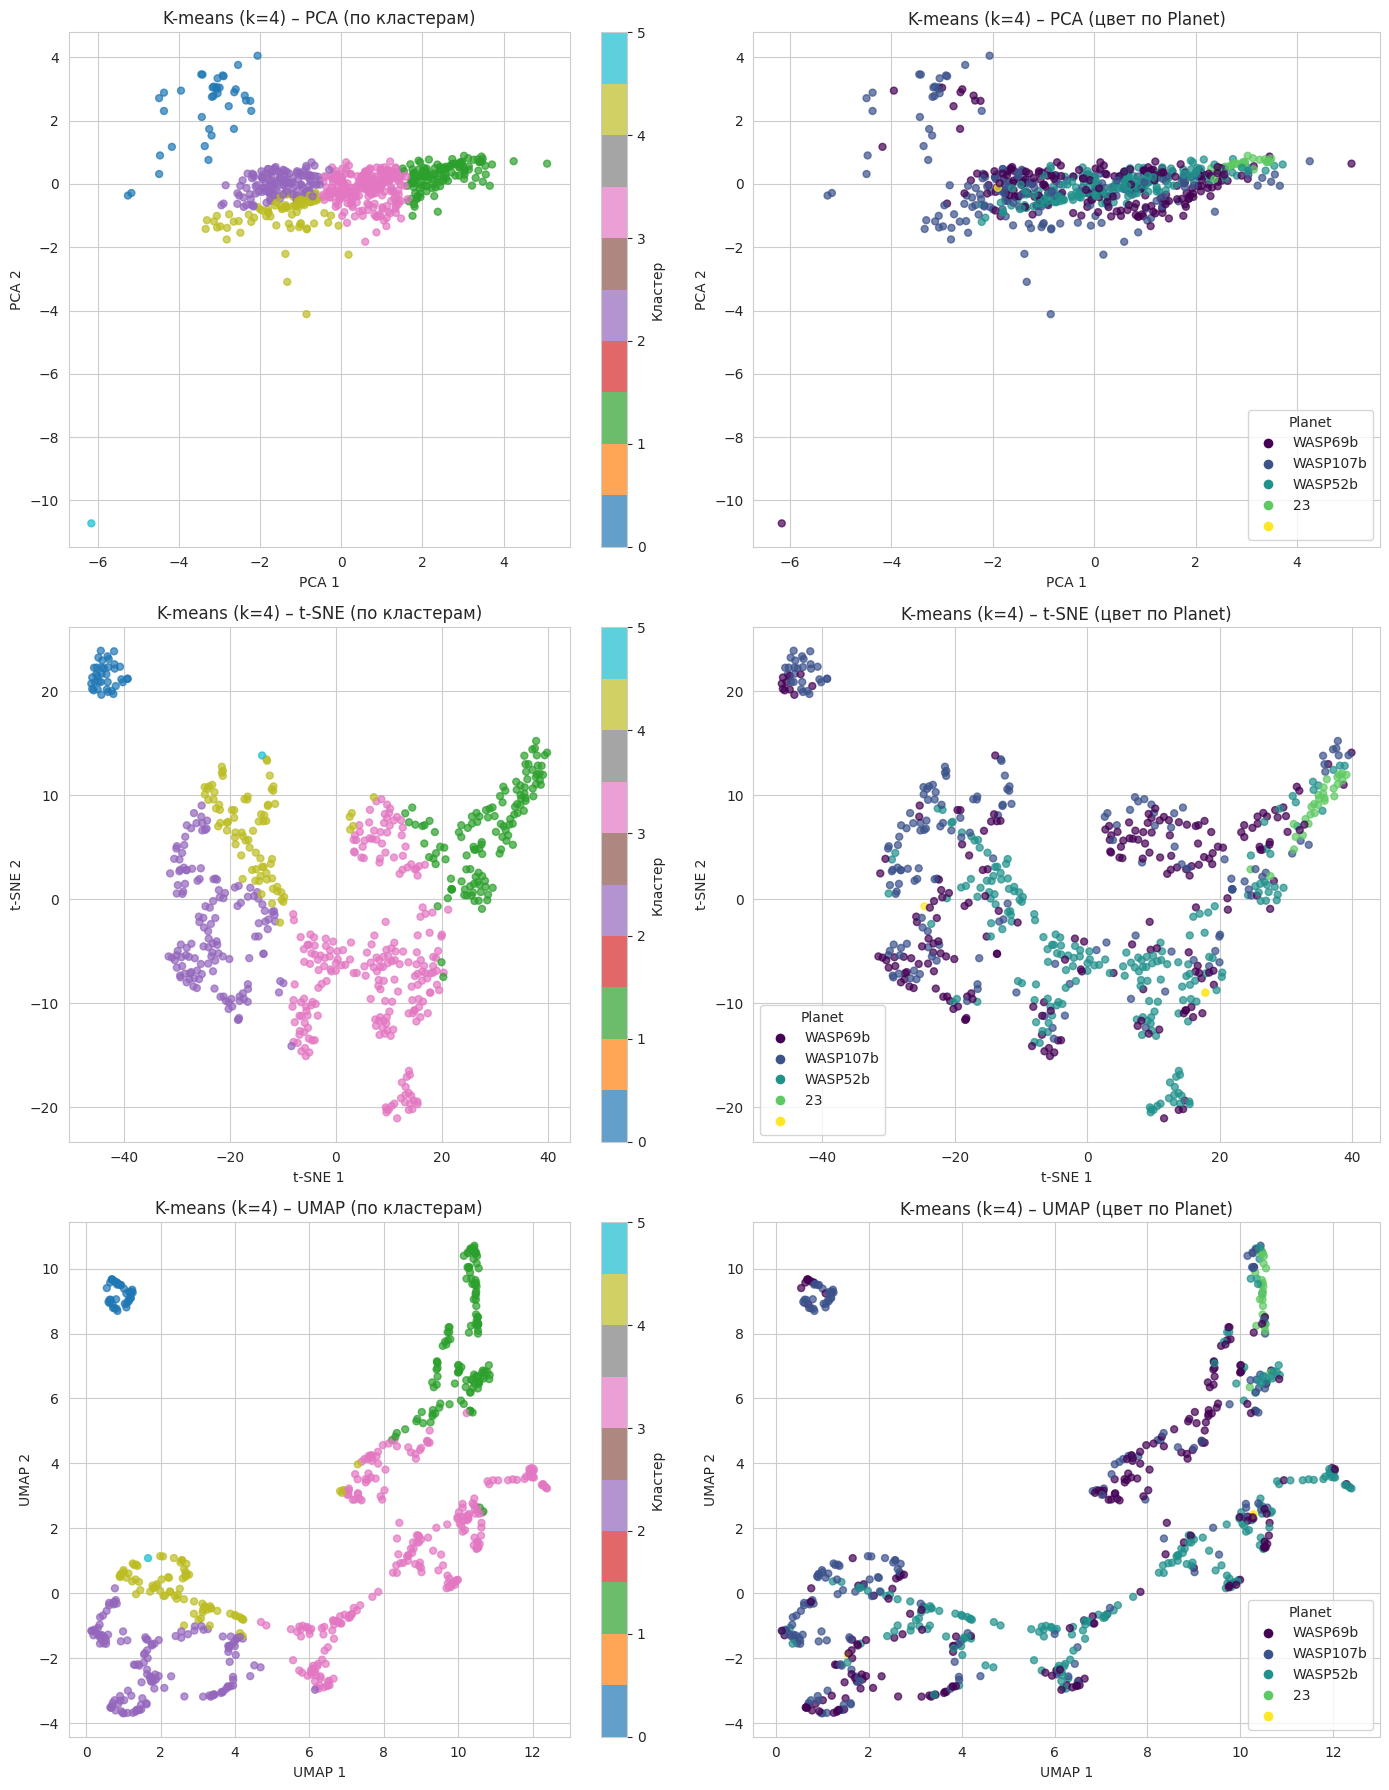

DBSCAN: число кластеров = 2, шумовых точек = 17


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.manifold import TSNE
# ============================================================
# 1. ЗАГРУЗИТЕ ВАШИ ДАННЫЕ (пример структуры)
# ============================================================
# Предположим, у вас есть DataFrame df с признаками (X) и целевыми переменными
# Для демонстрации сгенерируем синтетические данные, похожие на ваши

np.random.seed(42)
n = 614  # ваше число образцов
n_features = 5  # ваше число признаков

# Признаки
# X = np.random.randn(n, n_features)

# Целевые переменные (пример)
# df = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(n_features)])
# df['XUVInt'] = np.random.randint(1, 61, n)
# df['He_H'] = np.random.uniform(0.01, 0.3, n)
# df['logMsw'] = np.random.uniform(11, 13.7, n)
# df['planet'] = np.random.choice(['WASP-107b', 'WASP-69b', 'WASP-52b'], n)
df = dataset
feature_names = ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm']
target_names = ['XUVInt', 'Helium', 'Msw']
# Выбираем признаки для кластеризации
feature_cols = ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm']
X_scaled = StandardScaler().fit_transform(df[feature_cols])  # масштабирование обязательно

# ============================================================
# 2. ПОНИЖЕНИЕ РАЗМЕРНОСТИ ДЛЯ ВИЗУАЛИЗАЦИИ (PCA)
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE (нелинейный, хорошо показывает локальную структуру)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# UMAP (нелинейный, быстрее t-SNE, лучше сохраняет глобальную структуру)
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled)

# ============================================================
# 3. КЛАСТЕРИЗАЦИЯ K-MEANS
# ============================================================
# Подбираем число кластеров, например, по количеству планет + 1
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# ============================================================
# 4. КЛАСТЕРИЗАЦИЯ DBSCAN
# ============================================================
# Параметры подбираются эмпирически; eps контролирует плотность
dbscan = DBSCAN(eps=1.2, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ
# ============================================================
def plot_all_projections(X_pca, X_tsne, X_umap, labels, title_prefix, df, target_col='planet'):
    """
    Рисует 3 графика (PCA, t-SNE, UMAP) для заданных меток кластеров.
    Слева – цвет по кластерам, справа (в каждой проекции) – цвет по целевой переменной.
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 18))
    projections = [('PCA', X_pca), ('t-SNE', X_tsne), ('UMAP', X_umap)]
    
    for row, (proj_name, X_proj) in enumerate(projections):
        # Левый столбец: раскраска по кластерам
        scatter_left = axes[row, 0].scatter(X_proj[:, 0], X_proj[:, 1], c=labels, cmap='tab10', s=25, alpha=0.7)
        axes[row, 0].set_title(f'{title_prefix} – {proj_name} (по кластерам)')
        axes[row, 0].set_xlabel(f'{proj_name} 1')
        axes[row, 0].set_ylabel(f'{proj_name} 2')
        plt.colorbar(scatter_left, ax=axes[row, 0], label='Кластер')
        
        # Правый столбец: раскраска по целевой переменной
        if target_col == 'Planet':
            unique = df[target_col].unique()
            mapping = {cat: i for i, cat in enumerate(unique)}
            color_vals = df[target_col].map(mapping).values
            scatter_right = axes[row, 1].scatter(X_proj[:, 0], X_proj[:, 1], c=color_vals, cmap='viridis', s=25, alpha=0.7)
            handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.viridis(i/(len(unique)-1)), markersize=8) for i in range(len(unique))]
            axes[row, 1].legend(handles, unique, title=target_col)
        else:
            scatter_right = axes[row, 1].scatter(X_proj[:, 0], X_proj[:, 1], c=df[target_col], cmap='plasma', s=25, alpha=0.7)
            plt.colorbar(scatter_right, ax=axes[row, 1], label=target_col)
        
        axes[row, 1].set_title(f'{title_prefix} – {proj_name} (цвет по {target_col})')
        axes[row, 1].set_xlabel(f'{proj_name} 1')
        axes[row, 1].set_ylabel(f'{proj_name} 2')
    
    plt.tight_layout()
    plt.show()

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ
# ============================================================
# K-means
# plot_all_projections(X_pca, X_tsne, X_umap, kmeans_labels, 'K-means (k=4)', df, target_col='planet')
plot_all_projections(X_pca, X_tsne, X_umap, kmeans_labels, 'K-means (k=4)', df, target_col='Planet')

# DBSCAN
# plot_all_projections(X_pca, X_tsne, X_umap, dbscan_labels, 'DBSCAN (eps=1.2, minPts=10)', df, target_col='planet')
# plot_all_projections(X_pca, X_tsne, X_umap, dbscan_labels, 'DBSCAN (eps=1.2, minPts=10)', df, target_col='Planet')

# Дополнительно: выводим информацию о кластерах DBSCAN (шум и количество)
unique_db = np.unique(dbscan_labels)
n_clusters = len(unique_db[unique_db != -1])
noise = np.sum(dbscan_labels == -1)
print(f"DBSCAN: число кластеров = {n_clusters}, шумовых точек = {noise}")

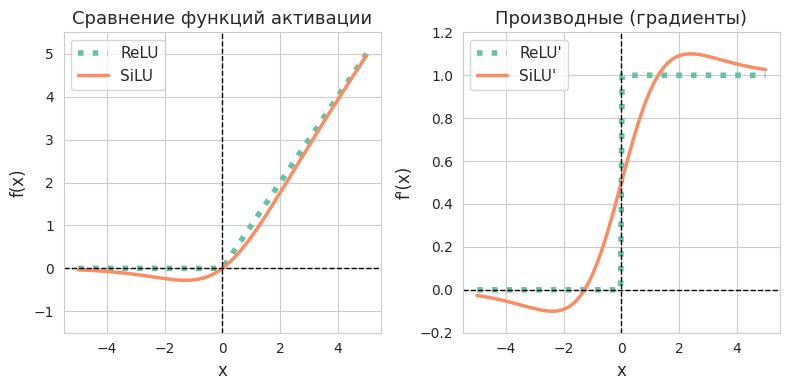

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Стиль
sns.set_style("whitegrid")
sns.set_palette("Set2")

# Данные
x = np.linspace(-5, 5, 200)
relu = np.maximum(0, x)
silu = x * 1/(1 + np.exp(-x))  # x * sigmoid(x)

# График 1: функции
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(x, relu, linewidth=4, label='ReLU', linestyle=":")
plt.plot(x, silu, linewidth=2.5, label='SiLU')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Сравнение функций активации', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(-1.5, 5.5)

# График 2: производные
plt.subplot(1, 2, 2)
# Производная ReLU: ступенька
relu_deriv = np.where(x > 0, 1, 0)
# Производная SiLU: sigmoid * (1 + x - x*sigmoid)
sigmoid = 1/(1 + np.exp(-x))
silu_deriv = sigmoid * (1 + x - x*sigmoid)

plt.plot(x, relu_deriv, linewidth=4, label='ReLU\'', linestyle=":")
plt.plot(x, silu_deriv, linewidth=2.5, label='SiLU\'')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('x', fontsize=12)
plt.ylabel("f'(x)", fontsize=12)
plt.title('Производные (градиенты)', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(-0.2, 1.2)

plt.tight_layout()
plt.show()

In [33]:
fixed_param1 = 1
fixed_param2 = 'A'
changeable_param = 'param3'

# Возвращаем строки с фиксированными параметрами и нужной колонкой
result = dataset[
    ((dataset['Planet'] == "WASP107b") | (dataset['Planet'] == '23')) &  
    (dataset['H2a'] == '0') &
    (dataset['Msw'] == "2e12")
]
result["XUVInt_t"] = result['XUVInt'].astype('float32')

/tmp/ipykernel_4138292/3906795021.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result["XUVInt_t"] = result['XUVInt'].astype('float32')


Распределение классов:
1.0    309
0.0    305
Name: count, dtype: int64



/home/kirill/diploma/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [07:10:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔍 ВАЖНОСТЬ ПРИЗНАКОВ

Топ-10 наиболее важных признаков:
  peak_x: 0.2637
  fwhm: 0.2067
  peak_y: 0.1836
  kurt: 0.1801
  skew: 0.1660
📊 Базовые метрики на тестовой выборке:
Accuracy:  0.6911
Precision: 0.7069
Recall:    0.6613
F1-Score:  0.6833
ROC-AUC:   0.7647

Classification Report:
              precision    recall  f1-score   support

         0.0       0.68      0.72      0.70        61
         1.0       0.71      0.66      0.68        62

    accuracy                           0.69       123
   macro avg       0.69      0.69      0.69       123
weighted avg       0.69      0.69      0.69       123


🔄 Выполняется бутстреп-оценка (1000 итераций)...

📈 Метрики с 95% доверительными интервалами:

ROC-AUC:
  Среднее:   0.7649
  Медиана:   0.7691
  95% CI:    (0.6799, 0.8397)
  Станд. отклонение: 0.0419

Accuracy:
  Среднее:   0.6913
  Медиана:   0.6911
  95% CI:    (0.6098, 0.7724)
  Станд. отклонение: 0.0418

Precision:
  Среднее:   0.7068
  Медиана:   0.7097
  95% CI:    (0.5833

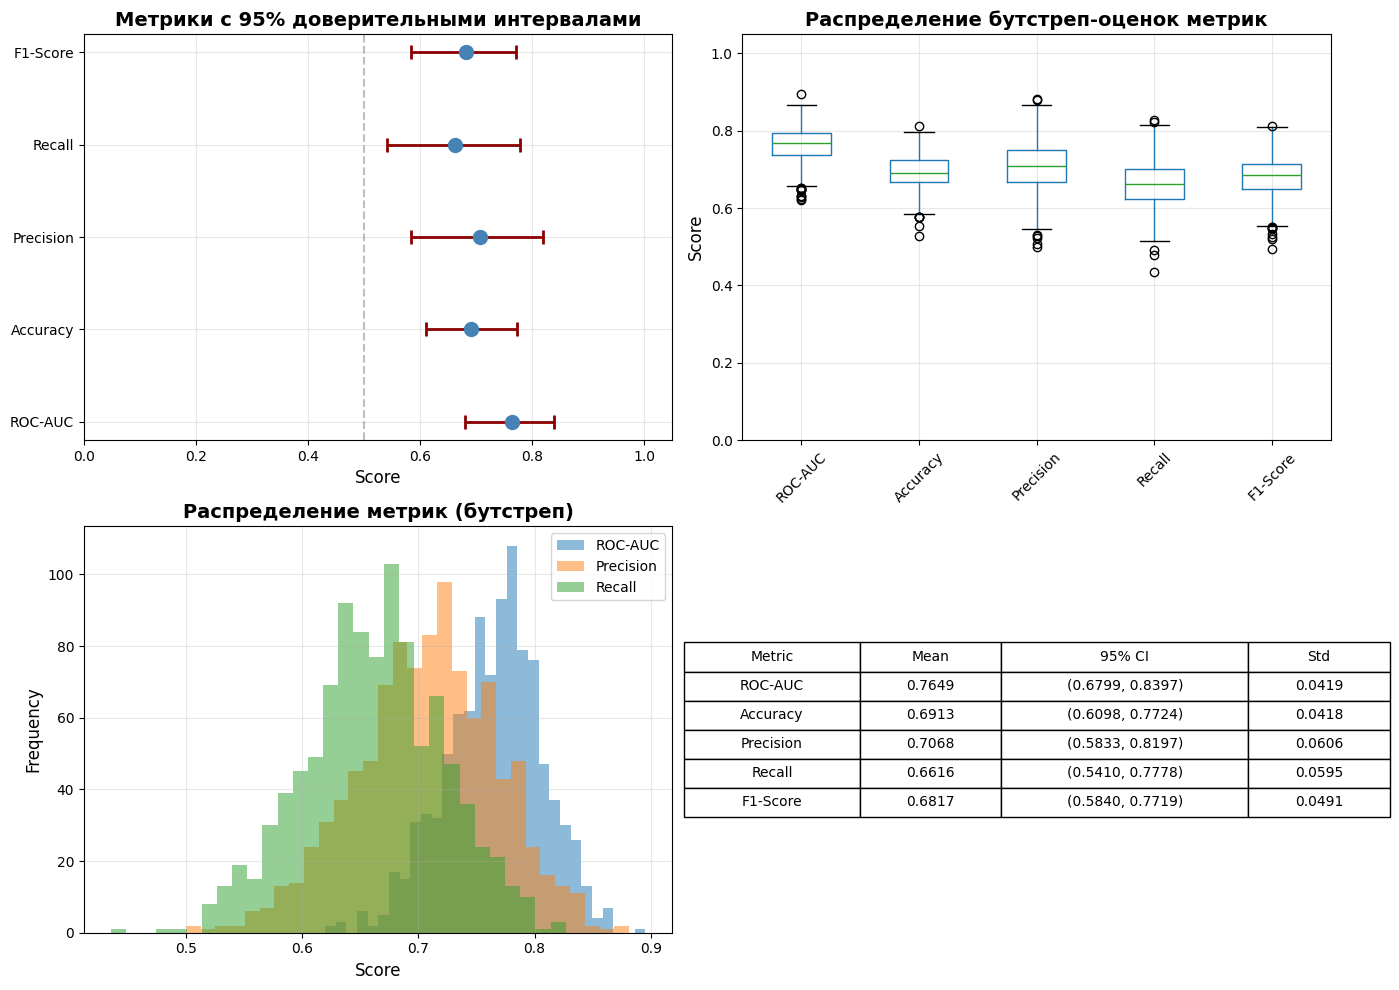

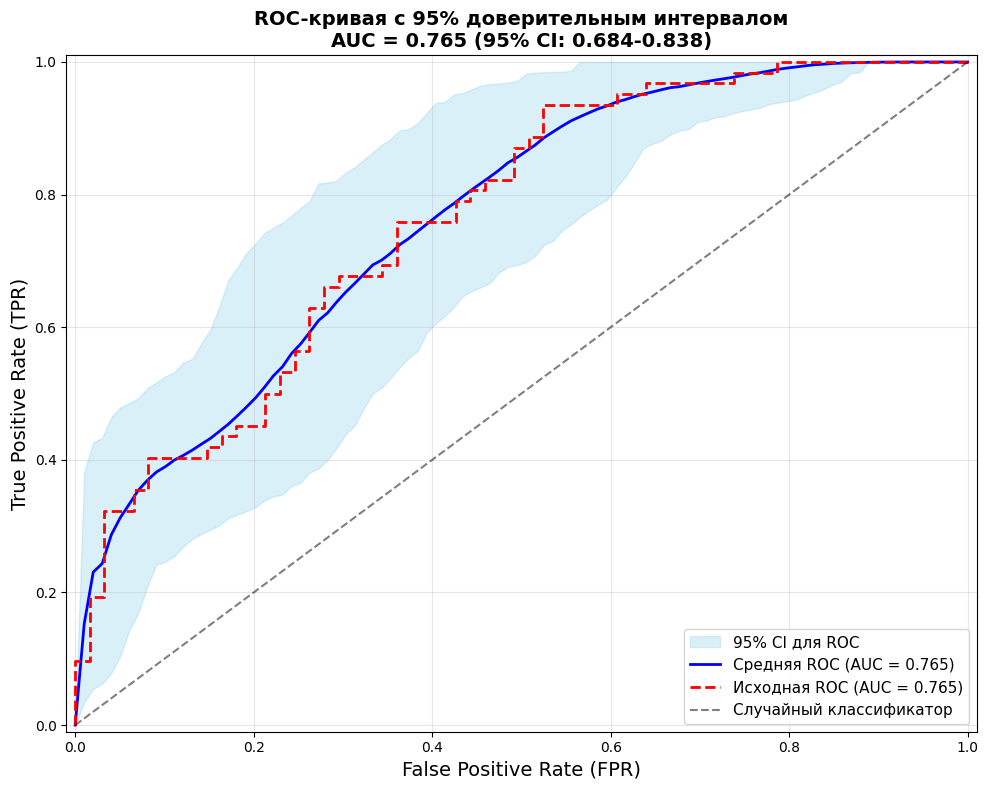

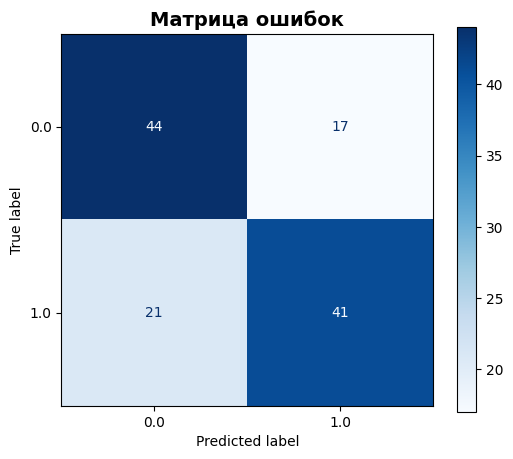

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import xgboost as xgb
from scipy import stats

# Для воспроизводимости
np.random.seed(42)

def bootstrap_metrics(y_true, y_pred_prob, n_bootstrap=1000, ci=95):
    """
    Оценка доверительных интервалов для метрик через бутстреп
    
    Parameters:
    -----------
    y_true : array-like
        Истинные метки классов
    y_pred_prob : array-like
        Предсказанные вероятности класса 1
    n_bootstrap : int
        Количество бутстреп-выборок
    ci : float
        Уровень доверия (по умолчанию 95%)
    
    Returns:
    --------
    metrics_stats : dict
        Словарь со статистиками для каждой метрики
    bootstrap_metrics_df : DataFrame
        Все бутстреп-значения метрик
    """
    n = len(y_true)
    y_pred_binary = (y_pred_prob >= 0.5).astype(int)
    
    # Хранилище для бутстреп-значений
    bootstrap_auc = []
    bootstrap_accuracy = []
    bootstrap_precision = []
    bootstrap_recall = []
    bootstrap_f1 = []
    
    # Порог для доверительного интервала
    alpha = (100 - ci) / 2
    percentiles = [alpha, 100 - alpha]
    
    for _ in range(n_bootstrap):
        # Случайная выборка с возвращением
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_true[indices]
        y_pred_prob_boot = y_pred_prob[indices]
        y_pred_binary_boot = (y_pred_prob_boot >= 0.5).astype(int)
        
        # Расчёт метрик
        try:
            bootstrap_auc.append(roc_auc_score(y_true_boot, y_pred_prob_boot))
        except:
            bootstrap_auc.append(np.nan)
            
        bootstrap_accuracy.append(accuracy_score(y_true_boot, y_pred_binary_boot))
        bootstrap_precision.append(precision_score(y_true_boot, y_pred_binary_boot, zero_division=0))
        bootstrap_recall.append(recall_score(y_true_boot, y_pred_binary_boot, zero_division=0))
        bootstrap_f1.append(f1_score(y_true_boot, y_pred_binary_boot, zero_division=0))
    
    # Функция для расчёта статистик
    def get_stats(values):
        values = np.array([v for v in values if not np.isnan(v)])
        return {
            'mean': np.mean(values),
            'std': np.std(values),
            'ci_lower': np.percentile(values, percentiles[0]),
            'ci_upper': np.percentile(values, percentiles[1]),
            'median': np.median(values)
        }
    
    # Сбор статистик
    metrics_stats = {
        'ROC-AUC': get_stats(bootstrap_auc),
        'Accuracy': get_stats(bootstrap_accuracy),
        'Precision': get_stats(bootstrap_precision),
        'Recall': get_stats(bootstrap_recall),
        'F1-Score': get_stats(bootstrap_f1)
    }
    
    # Создаём DataFrame с бутстреп-значениями для визуализации
    bootstrap_df = pd.DataFrame({
        'ROC-AUC': bootstrap_auc,
        'Accuracy': bootstrap_accuracy,
        'Precision': bootstrap_precision,
        'Recall': bootstrap_recall,
        'F1-Score': bootstrap_f1
    })
    
    return metrics_stats, bootstrap_df

def plot_metrics_with_cis(metrics_stats, bootstrap_df):
    """
    Визуализация метрик с доверительными интервалами (ИСПРАВЛЕННАЯ ВЕРСИЯ)
    """
    metrics_names = list(metrics_stats.keys())
    means = np.array([metrics_stats[m]['mean'] for m in metrics_names])
    ci_lower = np.array([metrics_stats[m]['ci_lower'] for m in metrics_names])
    ci_upper = np.array([metrics_stats[m]['ci_upper'] for m in metrics_names])
    
    # Вычисляем ошибки для errorbar
    lower_errors = means - ci_lower
    upper_errors = ci_upper - means
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Точки с CI
    ax1 = axes[0, 0]
    y_pos = np.arange(len(metrics_names))
    
    # Исправленный errorbar
    ax1.errorbar(means, y_pos, 
                 xerr=[lower_errors, upper_errors],  # Теперь передаем как кортеж
                 fmt='o', capsize=5, capthick=2, markersize=10, 
                 color='steelblue', ecolor='darkred', elinewidth=2)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(metrics_names)
    ax1.set_xlabel('Score', fontsize=12)
    ax1.set_title(f'Метрики с 95% доверительными интервалами', fontsize=14, fontweight='bold')
    ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1.05)
    
    # 2. Распределение bootstrap-значений
    ax2 = axes[0, 1]
    # Убираем NaN значения для boxplot
    bootstrap_df_clean = bootstrap_df.dropna()
    bootstrap_df_clean.boxplot(ax=ax2, rot=45)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_title('Распределение бутстреп-оценок метрик', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.05)
    
    # 3. Гистограммы распределений
    ax3 = axes[1, 0]
    for metric in ['ROC-AUC', 'Precision', 'Recall']:
        if metric in bootstrap_df.columns:
            data = bootstrap_df[metric].dropna()
            if len(data) > 0:
                ax3.hist(data, bins=30, alpha=0.5, label=metric)
    ax3.set_xlabel('Score', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Распределение метрик (бутстреп)', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Таблица со статистиками
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    table_data = []
    for metric in metrics_names:
        stats = metrics_stats[metric]
        table_data.append([
            metric,
            f"{stats['mean']:.4f}",
            f"({stats['ci_lower']:.4f}, {stats['ci_upper']:.4f})",
            f"{stats['std']:.4f}"
        ])
    
    table = ax4.table(cellText=table_data,
                      colLabels=['Metric', 'Mean', '95% CI', 'Std'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.25, 0.2, 0.35, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    plt.tight_layout()
    plt.show()

def plot_roc_curve_with_ci(y_test, y_pred_prob, n_bootstrap=1000, ci=95):
    """
    Построение ROC-кривой с доверительным интервалом
    """
    # Исходная ROC-кривая
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    auc_original = roc_auc_score(y_test, y_pred_prob)
    
    # Бутстреп для ROC-кривой
    n = len(y_test)
    all_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []
    
    for _ in range(n_bootstrap):
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_test[indices]
        y_pred_boot = y_pred_prob[indices]
        
        try:
            fpr_boot, tpr_boot, _ = roc_curve(y_true_boot, y_pred_boot)
            tpr_interp = np.interp(all_fpr, fpr_boot, tpr_boot)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        except:
            continue
    
    tprs = np.array(tprs)
    
    # Доверительный интервал для TPR при каждом FPR
    alpha = (100 - ci) / 2
    tpr_lower = np.percentile(tprs, alpha, axis=0)
    tpr_upper = np.percentile(tprs, 100 - alpha, axis=0)
    tpr_mean = np.mean(tprs, axis=0)
    
    # Доверительный интервал для AUC
    auc_ci_lower = np.percentile(aucs, alpha)
    auc_ci_upper = np.percentile(aucs, 100 - alpha)
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Доверительная область
    ax.fill_between(all_fpr, tpr_lower, tpr_upper, 
                    alpha=0.3, color='skyblue', 
                    label=f'{ci}% CI для ROC')
    
    # Средняя ROC-кривая
    ax.plot(all_fpr, tpr_mean, 'b-', linewidth=2, 
            label=f'Средняя ROC (AUC = {np.mean(aucs):.3f})')
    
    # Исходная ROC-кривая
    ax.plot(fpr, tpr, 'r--', linewidth=2, 
            label=f'Исходная ROC (AUC = {auc_original:.3f})')
    
    # Диагональ
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный классификатор')
    
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=14)
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=14)
    ax.set_title(f'ROC-кривая с {ci}% доверительным интервалом\n'
                f'AUC = {auc_original:.3f} (95% CI: {auc_ci_lower:.3f}-{auc_ci_upper:.3f})', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {'auc_mean': np.mean(aucs), 'auc_ci_lower': auc_ci_lower, 'auc_ci_upper': auc_ci_upper}

# ============ ОСНОВНАЯ ЧАСТЬ ============
# Генерация примера данных (замените на свои)
from sklearn.datasets import make_classification


feature_names = ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm']
X = dataset[feature_names].values.astype(np.float32)
y = dataset['H2a'].values.astype(np.float32)
print(f"Распределение классов:\n{pd.Series(y).value_counts()}")
print(f"{'='*50}\n")

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Обучение модели XGBoost
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train, y_train)

# Предсказания
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred_prob >= 0.5).astype(int)

print("\n" + "="*60)
print("🔍 ВАЖНОСТЬ ПРИЗНАКОВ")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 наиболее важных признаков:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")
# Базовые метрики
print("📊 Базовые метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_binary):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_binary):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_binary):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_binary):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_binary)}")
print("="*50 + "\n")

# Бутстреп-оценка метрик
print("🔄 Выполняется бутстреп-оценка (1000 итераций)...")
metrics_stats, bootstrap_df = bootstrap_metrics(y_test, y_pred_prob, n_bootstrap=1000, ci=95)

# Вывод результатов бутстрепа
print("\n📈 Метрики с 95% доверительными интервалами:")
for metric, stats in metrics_stats.items():
    print(f"\n{metric}:")
    print(f"  Среднее:   {stats['mean']:.4f}")
    print(f"  Медиана:   {stats['median']:.4f}")
    print(f"  95% CI:    ({stats['ci_lower']:.4f}, {stats['ci_upper']:.4f})")
    print(f"  Станд. отклонение: {stats['std']:.4f}")

# Визуализация метрик с CI
plot_metrics_with_cis(metrics_stats, bootstrap_df)

# ROC-кривая с доверительным интервалом
roc_ci = plot_roc_curve_with_ci(y_test, y_pred_prob, n_bootstrap=1000, ci=95)

# Дополнительно: матрица ошибок
fig, ax = plt.subplots(figsize=(6, 5))
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_binary, ax=ax, cmap='Blues')
plt.title('Матрица ошибок', fontsize=14, fontweight='bold')
plt.show()

📊 ПОДГОТОВКА ДАННЫХ С ONE-HOT ENCODING

📊 АНАЛИЗ КАТЕГОРИАЛЬНОГО ПРИЗНАКА: Planet

Распределение категорий:
  WASP69b: 207 (33.7%)
  WASP52b: 200 (32.6%)
  WASP107b: 176 (28.7%)
  23: 28 (4.6%)

Распределение целевой переменной по категориям:

  WASP69b:
    Class 0: 51.7%
    Class 1: 48.3%
    Размер: 207

  WASP107b:
    Class 0: 51.7%
    Class 1: 48.3%
    Размер: 176

  WASP52b:
    Class 0: 51.0%
    Class 1: 49.0%
    Размер: 200

  23:
    Class 0: 53.6%
    Class 1: 46.4%
    Размер: 28

  None:
    Class 0: 0.0%
    Class 1: 0.0%
    Размер: 0

🔄 ВЫПОЛНЯЕТСЯ ONE-HOT ENCODING...

Исходное количество признаков: 10
Количество признаков после one-hot encoding: 13
Новые признаки:
  - Planet_23
  - Planet_WASP107b
  - Planet_WASP52b
  - Planet_WASP69b

Финальная размерность X: (614, 9)
Признаки: ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm', 'Planet_23', 'Planet_WASP107b', 'Planet_WASP52b', 'Planet_WASP69b']

Распределение классов:
1.0    309
0.0    305
Name: count, dtype: int64

📊 

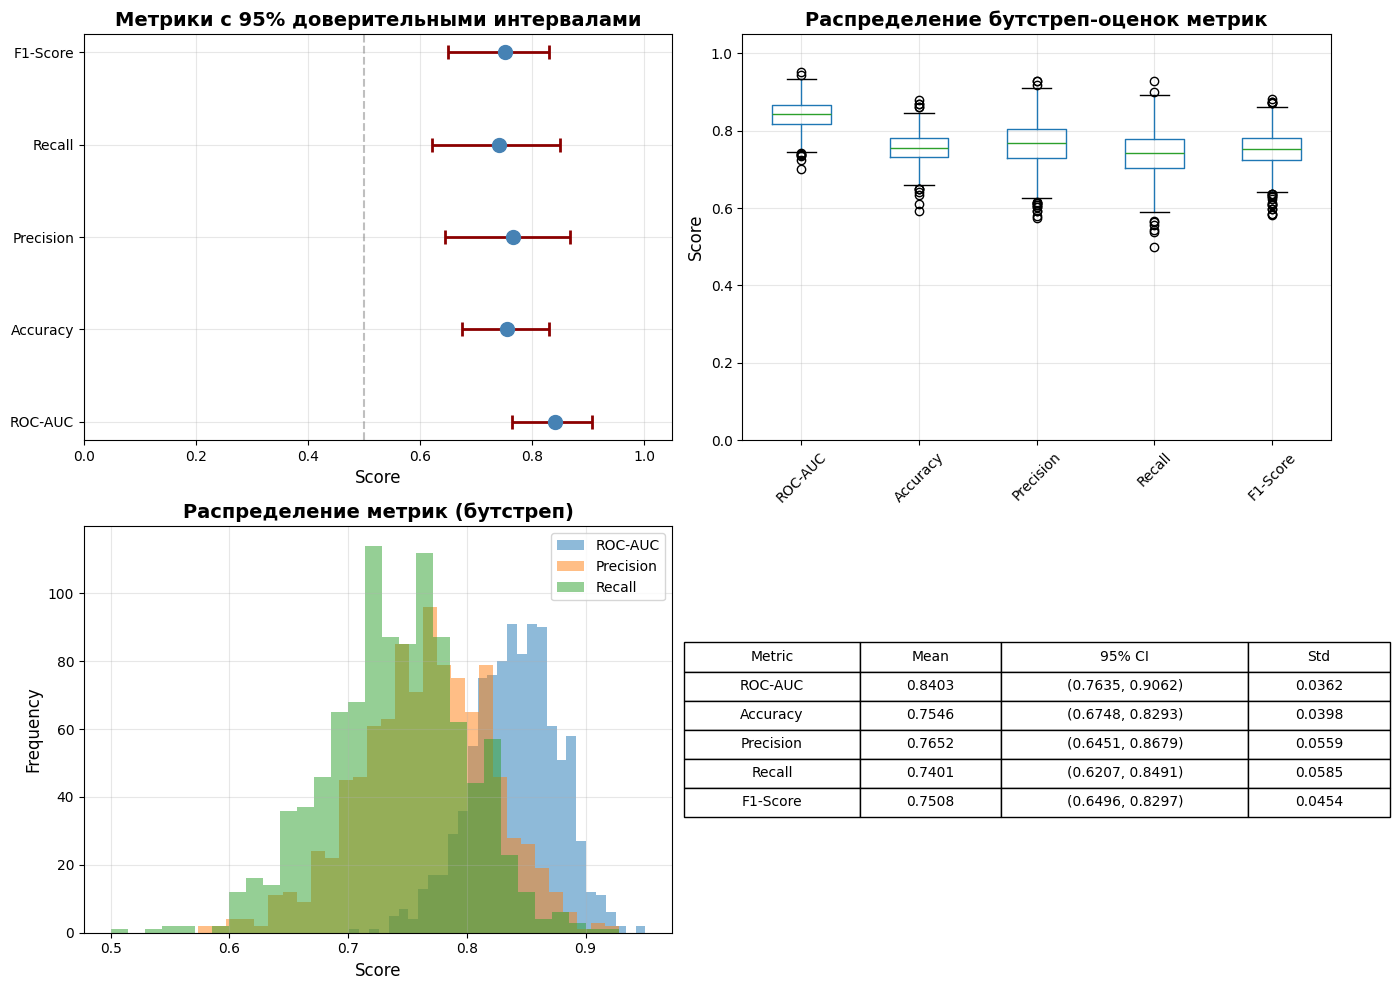

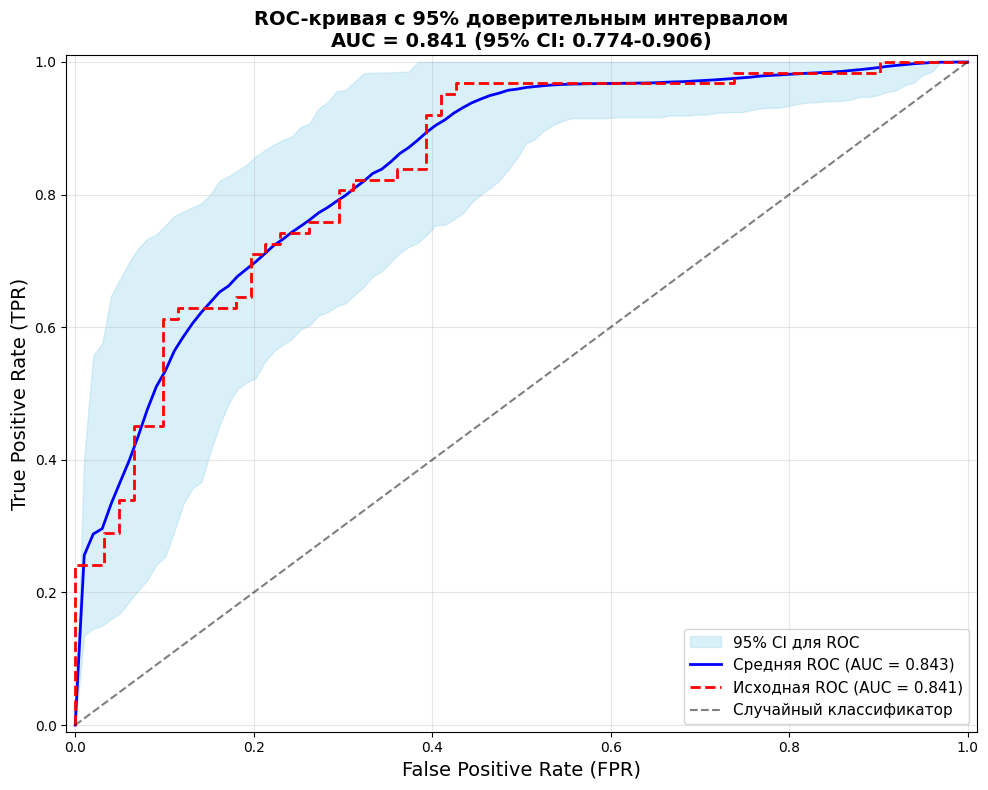

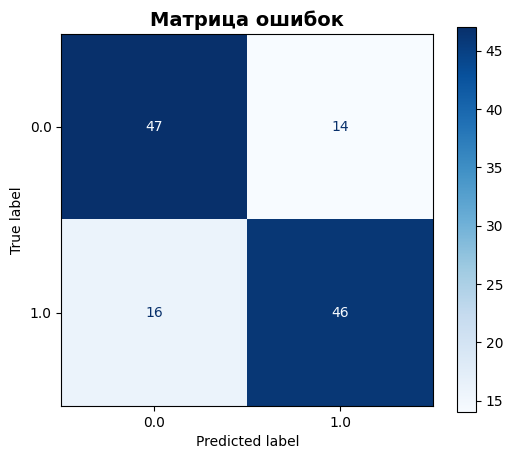


🔍 ВАЖНОСТЬ ПРИЗНАКОВ

Топ-10 наиболее важных признаков:
  peak_y: 0.1385
  Planet_23: 0.1299
  peak_x: 0.1299
  kurt: 0.1099
  Planet_WASP107b: 0.1078
  skew: 0.1001
  fwhm: 0.1000
  Planet_WASP52b: 0.0965
  Planet_WASP69b: 0.0874


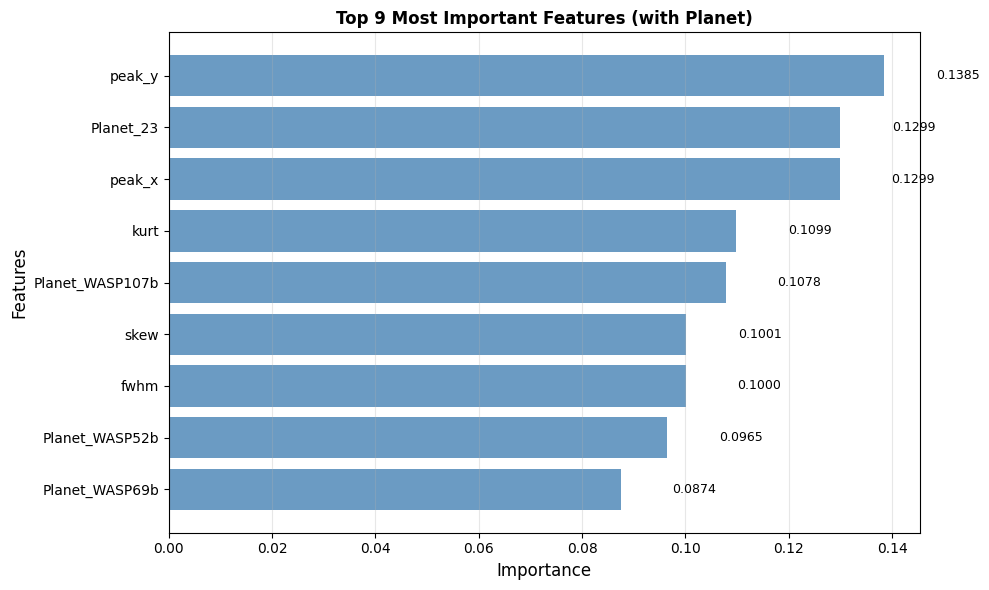


📊 АНАЛИЗ ПРЕДСКАЗАНИЙ ПО КАТЕГОРИЯМ PLANET

WASP69b:
  Размер выборки: 48
  Accuracy: 0.7292
  Recall (Class 1): 0.6818
  Средняя вероятность Class 1: 0.4378

WASP107b:
  Размер выборки: 30
  Accuracy: 0.7667
  Recall (Class 1): 0.8125
  Средняя вероятность Class 1: 0.4946

WASP52b:
  Размер выборки: 41
  Accuracy: 0.7561
  Recall (Class 1): 0.7273
  Средняя вероятность Class 1: 0.5094

23:
  Размер выборки: 4
  Accuracy: 1.0000
  Recall (Class 1): 1.0000
  Средняя вероятность Class 1: 0.3369


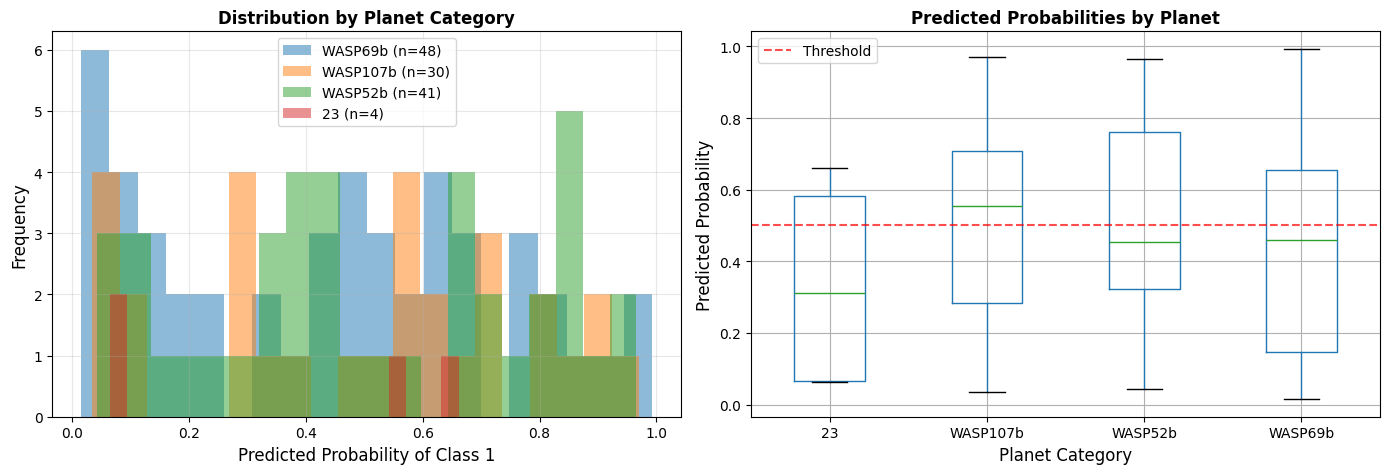


✅ Анализ завершён!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from scipy import stats

# Для воспроизводимости
np.random.seed(42)

def bootstrap_metrics(y_true, y_pred_prob, n_bootstrap=1000, ci=95):
    """
    Оценка доверительных интервалов для метрик через бутстреп
    """
    n = len(y_true)
    y_pred_binary = (y_pred_prob >= 0.5).astype(int)
    
    bootstrap_auc = []
    bootstrap_accuracy = []
    bootstrap_precision = []
    bootstrap_recall = []
    bootstrap_f1 = []
    
    alpha = (100 - ci) / 2
    percentiles = [alpha, 100 - alpha]
    
    for _ in range(n_bootstrap):
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_true[indices]
        y_pred_prob_boot = y_pred_prob[indices]
        y_pred_binary_boot = (y_pred_prob_boot >= 0.5).astype(int)
        
        try:
            bootstrap_auc.append(roc_auc_score(y_true_boot, y_pred_prob_boot))
        except:
            bootstrap_auc.append(np.nan)
            
        bootstrap_accuracy.append(accuracy_score(y_true_boot, y_pred_binary_boot))
        bootstrap_precision.append(precision_score(y_true_boot, y_pred_binary_boot, zero_division=0))
        bootstrap_recall.append(recall_score(y_true_boot, y_pred_binary_boot, zero_division=0))
        bootstrap_f1.append(f1_score(y_true_boot, y_pred_binary_boot, zero_division=0))
    
    def get_stats(values):
        values = np.array([v for v in values if not np.isnan(v)])
        return {
            'mean': np.mean(values),
            'std': np.std(values),
            'ci_lower': np.percentile(values, percentiles[0]),
            'ci_upper': np.percentile(values, percentiles[1]),
            'median': np.median(values)
        }
    
    metrics_stats = {
        'ROC-AUC': get_stats(bootstrap_auc),
        'Accuracy': get_stats(bootstrap_accuracy),
        'Precision': get_stats(bootstrap_precision),
        'Recall': get_stats(bootstrap_recall),
        'F1-Score': get_stats(bootstrap_f1)
    }
    
    bootstrap_df = pd.DataFrame({
        'ROC-AUC': bootstrap_auc,
        'Accuracy': bootstrap_accuracy,
        'Precision': bootstrap_precision,
        'Recall': bootstrap_recall,
        'F1-Score': bootstrap_f1
    })
    
    return metrics_stats, bootstrap_df

def plot_metrics_with_cis(metrics_stats, bootstrap_df):
    """Визуализация метрик с доверительными интервалами"""
    metrics_names = list(metrics_stats.keys())
    means = np.array([metrics_stats[m]['mean'] for m in metrics_names])
    ci_lower = np.array([metrics_stats[m]['ci_lower'] for m in metrics_names])
    ci_upper = np.array([metrics_stats[m]['ci_upper'] for m in metrics_names])
    
    lower_errors = means - ci_lower
    upper_errors = ci_upper - means
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Точки с CI
    ax1 = axes[0, 0]
    y_pos = np.arange(len(metrics_names))
    
    ax1.errorbar(means, y_pos, 
                 xerr=[lower_errors, upper_errors],
                 fmt='o', capsize=5, capthick=2, markersize=10, 
                 color='steelblue', ecolor='darkred', elinewidth=2)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(metrics_names)
    ax1.set_xlabel('Score', fontsize=12)
    ax1.set_title(f'Метрики с 95% доверительными интервалами', fontsize=14, fontweight='bold')
    ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1.05)
    
    # 2. Распределение bootstrap-значений
    ax2 = axes[0, 1]
    bootstrap_df_clean = bootstrap_df.dropna()
    bootstrap_df_clean.boxplot(ax=ax2, rot=45)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_title('Распределение бутстреп-оценок метрик', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.05)
    
    # 3. Гистограммы распределений
    ax3 = axes[1, 0]
    for metric in ['ROC-AUC', 'Precision', 'Recall']:
        if metric in bootstrap_df.columns:
            data = bootstrap_df[metric].dropna()
            if len(data) > 0:
                ax3.hist(data, bins=30, alpha=0.5, label=metric)
    ax3.set_xlabel('Score', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Распределение метрик (бутстреп)', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Таблица со статистиками
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    table_data = []
    for metric in metrics_names:
        stats = metrics_stats[metric]
        table_data.append([
            metric,
            f"{stats['mean']:.4f}",
            f"({stats['ci_lower']:.4f}, {stats['ci_upper']:.4f})",
            f"{stats['std']:.4f}"
        ])
    
    table = ax4.table(cellText=table_data,
                      colLabels=['Metric', 'Mean', '95% CI', 'Std'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.25, 0.2, 0.35, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    plt.tight_layout()
    plt.show()

def plot_roc_curve_with_ci(y_test, y_pred_prob, n_bootstrap=1000, ci=95):
    """Построение ROC-кривой с доверительным интервалом"""
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    auc_original = roc_auc_score(y_test, y_pred_prob)
    
    n = len(y_test)
    all_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []
    
    for _ in range(n_bootstrap):
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_test[indices]
        y_pred_boot = y_pred_prob[indices]
        
        try:
            fpr_boot, tpr_boot, _ = roc_curve(y_true_boot, y_pred_boot)
            tpr_interp = np.interp(all_fpr, fpr_boot, tpr_boot)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
            aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        except:
            continue
    
    tprs = np.array(tprs)
    alpha = (100 - ci) / 2
    tpr_lower = np.percentile(tprs, alpha, axis=0)
    tpr_upper = np.percentile(tprs, 100 - alpha, axis=0)
    tpr_mean = np.mean(tprs, axis=0)
    
    auc_ci_lower = np.percentile(aucs, alpha)
    auc_ci_upper = np.percentile(aucs, 100 - alpha)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.fill_between(all_fpr, tpr_lower, tpr_upper, 
                    alpha=0.3, color='skyblue', 
                    label=f'{ci}% CI для ROC')
    
    ax.plot(all_fpr, tpr_mean, 'b-', linewidth=2, 
            label=f'Средняя ROC (AUC = {np.mean(aucs):.3f})')
    
    ax.plot(fpr, tpr, 'r--', linewidth=2, 
            label=f'Исходная ROC (AUC = {auc_original:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный классификатор')
    
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=14)
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=14)
    ax.set_title(f'ROC-кривая с {ci}% доверительным интервалом\n'
                f'AUC = {auc_original:.3f} (95% CI: {auc_ci_lower:.3f}-{auc_ci_upper:.3f})', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {'auc_mean': np.mean(aucs), 'auc_ci_lower': auc_ci_lower, 'auc_ci_upper': auc_ci_upper}

def analyze_categorical_feature(dataset, feature_name='Planet'):
    """
    Анализ категориального признака Planet
    """
    print("\n" + "="*60)
    print(f"📊 АНАЛИЗ КАТЕГОРИАЛЬНОГО ПРИЗНАКА: {feature_name}")
    print("="*60)
    
    # Статистика по категориям
    print(f"\nРаспределение категорий:")
    category_counts = dataset[feature_name].value_counts()
    for cat, count in category_counts.items():
        print(f"  {cat}: {count} ({count/len(dataset)*100:.1f}%)")
    
    # Распределение целевой переменной по категориям
    print(f"\nРаспределение целевой переменной по категориям:")
    for cat in dataset[feature_name].unique():
        subset = dataset[dataset[feature_name] == cat]
        h2a_dist = subset['H2a'].value_counts(normalize=True)
        print(f"\n  {cat}:")
        print(f"    Class 0: {h2a_dist.get(0, 0)*100:.1f}%")
        print(f"    Class 1: {h2a_dist.get(1, 0)*100:.1f}%")
        print(f"    Размер: {len(subset)}")

# ============ ОСНОВНАЯ ЧАСТЬ ============
# Загрузка и подготовка данных
# Предполагается, что dataset уже загружен и содержит нужные колонки

# Определяем признаки
numeric_features = ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm']
categorical_features = ['Planet']  # категориальный признак

print("="*60)
print("📊 ПОДГОТОВКА ДАННЫХ С ONE-HOT ENCODING")
print("="*60)

# Анализ категориального признака
analyze_categorical_feature(dataset, 'Planet')

# Создаем копию данных для обработки
df_processed = dataset.copy()

# Вариант 1: Ручной one-hot encoding с pandas get_dummies
print("\n" + "="*60)
print("🔄 ВЫПОЛНЯЕТСЯ ONE-HOT ENCODING...")
print("="*60)

# Применяем one-hot encoding к категориальному признаку
df_encoded = pd.get_dummies(df_processed, columns=categorical_features, prefix=categorical_features, drop_first=False)

# Выводим информацию о созданных признаках
print(f"\nИсходное количество признаков: {len(df_processed.columns)}")
print(f"Количество признаков после one-hot encoding: {len(df_encoded.columns)}")
print(f"Новые признаки:")
for col in df_encoded.columns:
    if col not in df_processed.columns:
        print(f"  - {col}")

# Подготавливаем X (признаки) и y (целевая переменная)
# Исключаем целевую переменную 'H2a' из признаков
feature_columns = numeric_features + [col for col in df_encoded.columns if col.startswith('Planet_')]
X = df_encoded[feature_columns].values.astype(np.float32)
y = dataset['H2a'].values.astype(np.float32)

# Сохраняем имена признаков для интерпретации
feature_names = feature_columns

print(f"\nФинальная размерность X: {X.shape}")
print(f"Признаки: {feature_names}")

print(f"\nРаспределение классов:")
print(pd.Series(y).value_counts())
print(f"{'='*50}\n")

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Обучение модели XGBoost
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train, y_train)

# Предсказания
y_pred_prob_2 = model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred_prob_2 >= 0.5).astype(int)

# Базовые метрики
print("📊 Базовые метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_binary):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_binary):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_binary):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_binary):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_prob_2):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_binary)}")
print("="*50 + "\n")

# Бутстреп-оценка метрик
print("🔄 Выполняется бутстреп-оценка (1000 итераций)...")
metrics_stats, bootstrap_df = bootstrap_metrics(y_test, y_pred_prob_2, n_bootstrap=1000, ci=95)

# Вывод результатов бутстрепа
print("\n📈 Метрики с 95% доверительными интервалами:")
for metric, stats in metrics_stats.items():
    print(f"\n{metric}:")
    print(f"  Среднее:   {stats['mean']:.4f}")
    print(f"  Медиана:   {stats['median']:.4f}")
    print(f"  95% CI:    ({stats['ci_lower']:.4f}, {stats['ci_upper']:.4f})")
    print(f"  Станд. отклонение: {stats['std']:.4f}")

# Визуализация метрик с CI
plot_metrics_with_cis(metrics_stats, bootstrap_df)

# ROC-кривая с доверительным интервалом
roc_ci = plot_roc_curve_with_ci(y_test, y_pred_prob_2, n_bootstrap=1000, ci=95)

# Дополнительно: матрица ошибок
fig, ax = plt.subplots(figsize=(6, 5))
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_binary, ax=ax, cmap='Blues')
plt.title('Матрица ошибок', fontsize=14, fontweight='bold')
plt.show()

# Анализ важности признаков (с учетом one-hot encoded признаков)
print("\n" + "="*60)
print("🔍 ВАЖНОСТЬ ПРИЗНАКОВ")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 наиболее важных признаков:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Визуализация важности признаков
fig, ax = plt.subplots(figsize=(10, 6))

top_n = min(10, len(feature_importance))
top_features = feature_importance.head(top_n)
importance_values = top_features['importance'].values
feature_names_plot = top_features['feature'].values

# Создаем горизонтальные бары
y_pos = np.arange(len(importance_values))
ax.barh(y_pos, importance_values, color='steelblue', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names_plot)
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features (with Planet)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Добавляем значения
for i, v in enumerate(importance_values):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Дополнительный анализ: сравнение предсказаний по категориям Planet
print("\n" + "="*60)
print("📊 АНАЛИЗ ПРЕДСКАЗАНИЙ ПО КАТЕГОРИЯМ PLANET")
print("="*60)

# Добавляем обратно категории Planet для анализа
df_test = dataset.iloc[X_test.index if hasattr(X_test, 'index') else range(len(X_test))].copy()
df_test['Predicted_Prob'] = y_pred_prob_2
df_test['Predicted_Class'] = y_pred_binary
df_test['True_Class'] = y_test

# Анализ по категориям
for planet in df_test['Planet'].unique():
    subset = df_test[df_test['Planet'] == planet]
    if len(subset) > 0:
        print(f"\n{planet}:")
        print(f"  Размер выборки: {len(subset)}")
        print(f"  Accuracy: {accuracy_score(subset['True_Class'], subset['Predicted_Class']):.4f}")
        if len(subset[subset['True_Class'] == 1]) > 0:
            print(f"  Recall (Class 1): {recall_score(subset['True_Class'], subset['Predicted_Class']):.4f}")
        print(f"  Средняя вероятность Class 1: {subset['Predicted_Prob'].mean():.4f}")

# Визуализация по категориям Planet
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Распределение вероятностей по категориям
ax1 = axes[0]
for planet in df_test['Planet'].unique():
    subset = df_test[df_test['Planet'] == planet]
    ax1.hist(subset['Predicted_Prob'], bins=20, alpha=0.5, label=f"{planet} (n={len(subset)})")
ax1.set_xlabel('Predicted Probability of Class 1', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution by Planet Category', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Boxplot вероятностей по категориям
ax2 = axes[1]
df_test.boxplot(column='Predicted_Prob', by='Planet', ax=ax2)
ax2.set_xlabel('Planet Category', fontsize=12)
ax2.set_ylabel('Predicted Probability', fontsize=12)
ax2.set_title('Predicted Probabilities by Planet', fontsize=12, fontweight='bold')
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold')
ax2.legend()
plt.suptitle('')  # Убираем автоматический заголовок
plt.tight_layout()
plt.show()

print("\n✅ Анализ завершён!")

In [24]:
top_3 = dataset['Helium'].value_counts().head(10)
top_3

Helium
0.03022     41
0.02022     16
0.010022    12
0.042022    11
0.032022    10
0.065022    10
0.105022    10
0.030022     9
0.024022     9
0.092022     9
Name: count, dtype: int64


🚀 ЗАПУСК СРАВНЕНИЯ МОДЕЛЕЙ

Размерность X_base: (614, 5)
Размерность X_with_planet: (614, 9)

🔄 Обучение модели без Planet...
🔄 Обучение модели с Planet...

📊 СРАВНЕНИЕ ROC-КРИВЫХ: Model without Planet vs Model with Planet
Запуск бутстреп-анализа (2000 итераций)...
  Прогресс: 500/2000 итераций
  Прогресс: 1000/2000 итераций
  Прогресс: 1500/2000 итераций
  Прогресс: 2000/2000 итераций

📈 РЕЗУЛЬТАТЫ СРАВНЕНИЯ

Model without Planet:
  AUC = 0.7790 (95% CI: 0.6863-0.8548)

Model with Planet:
  AUC = 0.8406 (95% CI: 0.7640-0.9041)

Разница AUC (Model without Planet - Model with Planet):
  Среднее = -0.061955
  95% CI = (-0.110045, -0.018002)
  p-value = 0.006000

  ✅ Статистически значимое различие: Model with Planet лучше Model without Planet (p < 0.05)


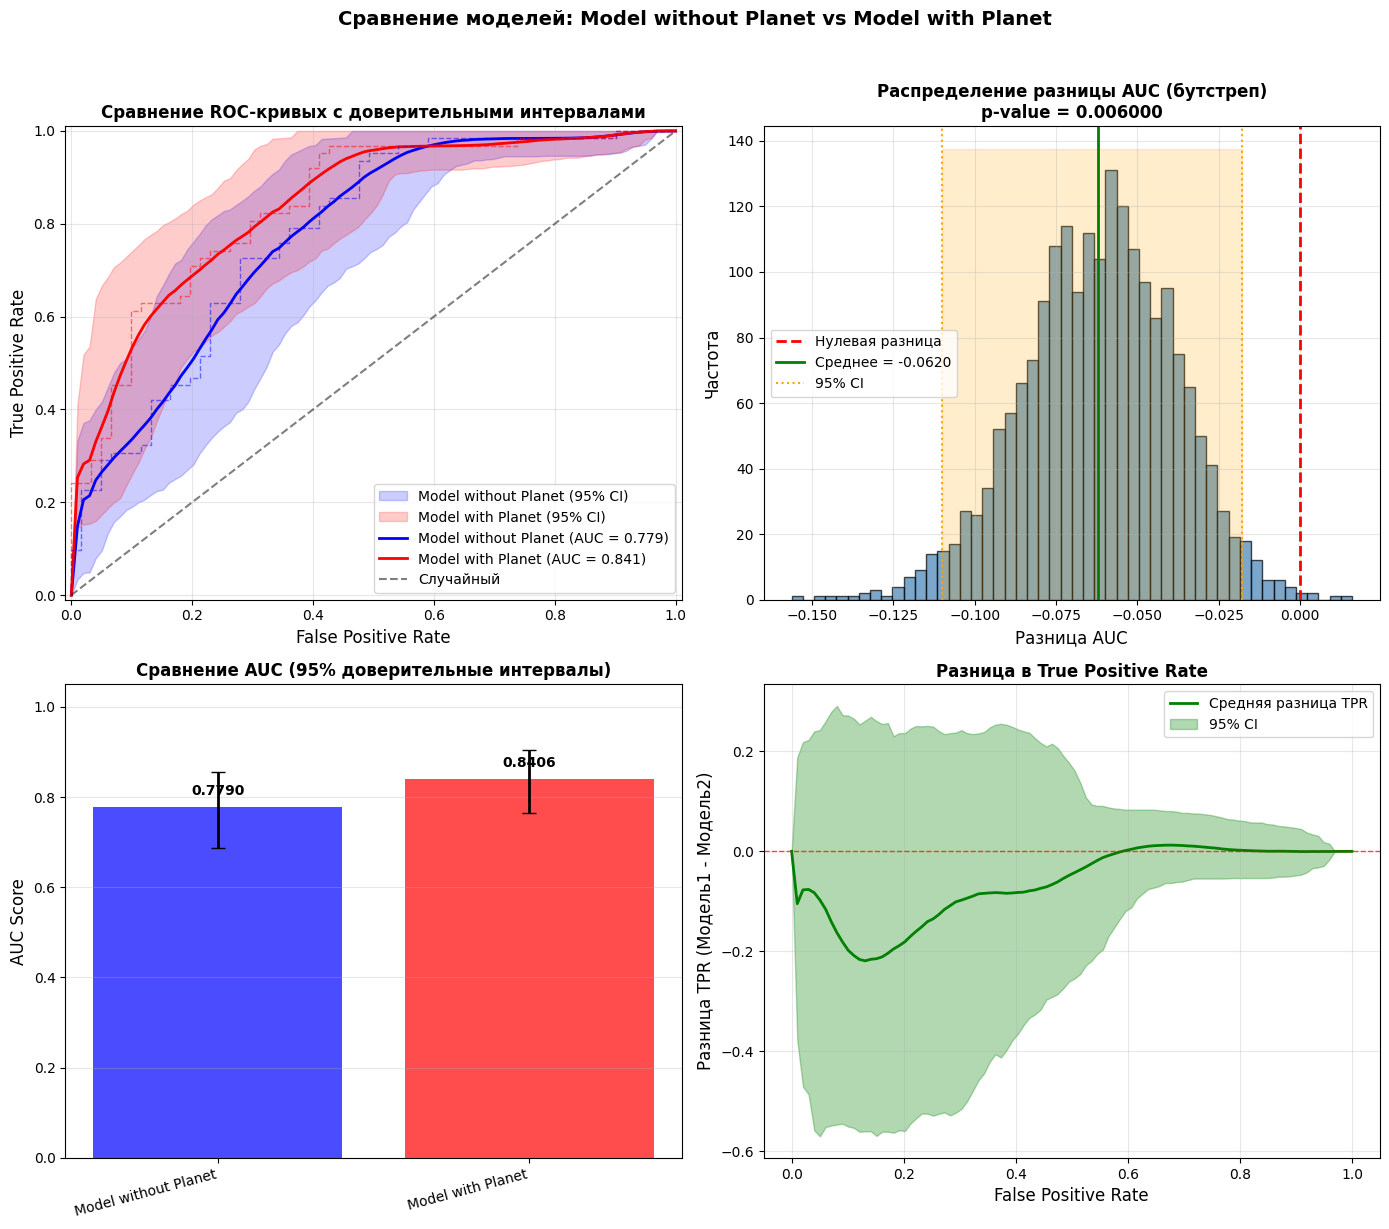

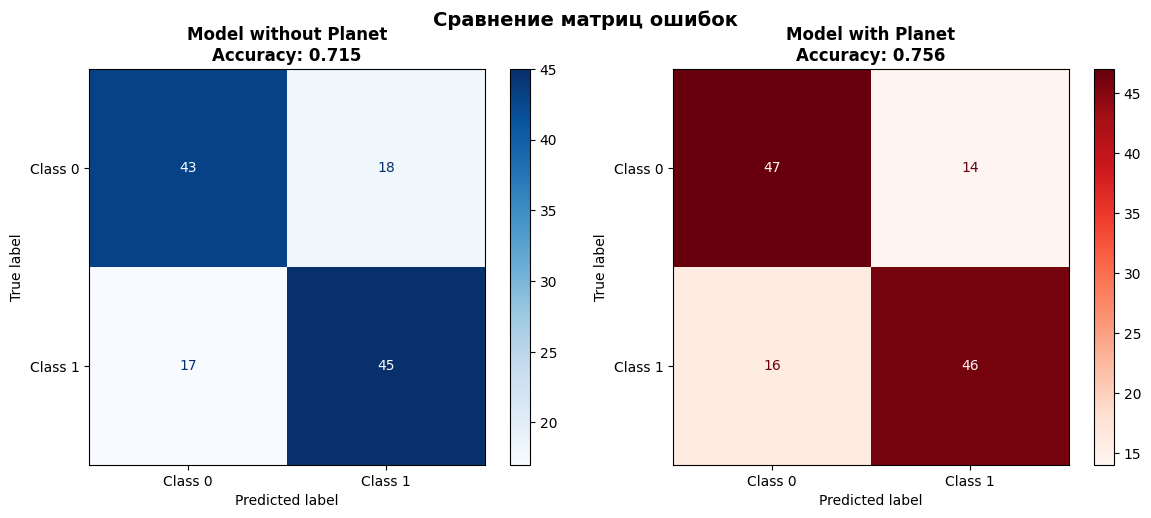


📊 ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ
Effect size (Cohen's d): -1.5688
  Интерпретация: большой эффект

🎯 ФИНАЛЬНЫЙ ВЕРДИКТ
✅ Model with Planet статистически значимо лучше!
   Улучшение AUC: -0.0620
   p-value: 0.006000


In [8]:
def compare_roc_curves(y_test, y_pred_prob1, y_pred_prob2, 
                       model_name1='Model 1', model_name2='Model 2',
                       n_bootstrap=2000, ci=95, alpha=0.05):
    """
    Сравнение двух ROC-кривых с доверительными интервалами (ИСПРАВЛЕННАЯ ВЕРСИЯ)
    """
    
    n = len(y_test)
    all_fpr = np.linspace(0, 1, 100)
    
    # Исходные метрики
    auc1 = roc_auc_score(y_test, y_pred_prob1)
    auc2 = roc_auc_score(y_test, y_pred_prob2)
    fpr1, tpr1, _ = roc_curve(y_test, y_pred_prob1)
    fpr2, tpr2, _ = roc_curve(y_test, y_pred_prob2)
    
    # Хранилища для бутстреп-значений
    aucs1 = []
    aucs2 = []
    auc_diffs = []
    tprs1 = []
    tprs2 = []
    
    # Пороги для CI
    alpha_ci = (100 - ci) / 2
    percentiles = [alpha_ci, 100 - alpha_ci]
    
    print(f"\n{'='*70}")
    print(f"📊 СРАВНЕНИЕ ROC-КРИВЫХ: {model_name1} vs {model_name2}")
    print(f"{'='*70}")
    print(f"Запуск бутстреп-анализа ({n_bootstrap} итераций)...")
    
    for i in range(n_bootstrap):
        if (i + 1) % 500 == 0:
            print(f"  Прогресс: {i+1}/{n_bootstrap} итераций")
            
        indices = np.random.choice(n, size=n, replace=True)
        y_true_boot = y_test[indices]
        y_pred_boot1 = y_pred_prob1[indices]
        y_pred_boot2 = y_pred_prob2[indices]
        
        try:
            # AUC для каждой модели
            auc_boot1 = roc_auc_score(y_true_boot, y_pred_boot1)
            auc_boot2 = roc_auc_score(y_true_boot, y_pred_boot2)
            aucs1.append(auc_boot1)
            aucs2.append(auc_boot2)
            auc_diffs.append(auc_boot1 - auc_boot2)
            
            # TPR для ROC-кривых
            fpr_boot1, tpr_boot1, _ = roc_curve(y_true_boot, y_pred_boot1)
            fpr_boot2, tpr_boot2, _ = roc_curve(y_true_boot, y_pred_boot2)
            
            tpr_interp1 = np.interp(all_fpr, fpr_boot1, tpr_boot1)
            tpr_interp2 = np.interp(all_fpr, fpr_boot2, tpr_boot2)
            tpr_interp1[0] = 0.0
            tpr_interp2[0] = 0.0
            
            tprs1.append(tpr_interp1)
            tprs2.append(tpr_interp2)
        except Exception as e:
            continue
    
    # Преобразуем в numpy массивы
    aucs1 = np.array(aucs1)
    aucs2 = np.array(aucs2)
    auc_diffs = np.array(auc_diffs)
    tprs1 = np.array(tprs1)
    tprs2 = np.array(tprs2)
    
    # Доверительные интервалы для AUC
    auc1_ci_lower = np.percentile(aucs1, percentiles[0])
    auc1_ci_upper = np.percentile(aucs1, percentiles[1])
    auc2_ci_lower = np.percentile(aucs2, percentiles[0])
    auc2_ci_upper = np.percentile(aucs2, percentiles[1])
    
    # Доверительные интервалы для разницы AUC
    diff_mean = np.mean(auc_diffs)
    diff_ci_lower = np.percentile(auc_diffs, percentiles[0])
    diff_ci_upper = np.percentile(auc_diffs, percentiles[1])
    
    # Статистический тест (p-value для разницы AUC)
    # Исправленная строка - преобразуем в numpy массив для сравнения
    auc_diffs_array = np.array(auc_diffs)
    p_value = 2 * min(np.mean(auc_diffs_array > 0), np.mean(auc_diffs_array < 0))
    
    # Доверительные интервалы для TPR
    if len(tprs1) > 0 and len(tprs2) > 0:
        tpr1_mean = np.mean(tprs1, axis=0)
        tpr2_mean = np.mean(tprs2, axis=0)
        tpr1_lower = np.percentile(tprs1, percentiles[0], axis=0)
        tpr1_upper = np.percentile(tprs1, percentiles[1], axis=0)
        tpr2_lower = np.percentile(tprs2, percentiles[0], axis=0)
        tpr2_upper = np.percentile(tprs2, percentiles[1], axis=0)
    else:
        tpr1_mean = tpr2_mean = tpr1_lower = tpr1_upper = tpr2_lower = tpr2_upper = None
    
    # Вывод результатов
    print(f"\n{'='*70}")
    print("📈 РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
    print(f"{'='*70}")
    
    print(f"\n{model_name1}:")
    print(f"  AUC = {auc1:.4f} ({ci}% CI: {auc1_ci_lower:.4f}-{auc1_ci_upper:.4f})")
    
    print(f"\n{model_name2}:")
    print(f"  AUC = {auc2:.4f} ({ci}% CI: {auc2_ci_lower:.4f}-{auc2_ci_upper:.4f})")
    
    print(f"\nРазница AUC ({model_name1} - {model_name2}):")
    print(f"  Среднее = {diff_mean:.6f}")
    print(f"  {ci}% CI = ({diff_ci_lower:.6f}, {diff_ci_upper:.6f})")
    print(f"  p-value = {p_value:.6f}")
    
    if p_value < alpha:
        if diff_mean > 0:
            print(f"\n  ✅ Статистически значимое различие: {model_name1} лучше {model_name2} (p < {alpha})")
        else:
            print(f"\n  ✅ Статистически значимое различие: {model_name2} лучше {model_name1} (p < {alpha})")
    else:
        print(f"\n  ❌ Нет статистически значимого различия между моделями (p = {p_value:.4f} >= {alpha})")
    
    # Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. ROC-кривые с CI
    ax1 = axes[0, 0]
    
    if tpr1_lower is not None:
        # Доверительные области
        ax1.fill_between(all_fpr, tpr1_lower, tpr1_upper, 
                         alpha=0.2, color='blue', label=f'{model_name1} ({ci}% CI)')
        ax1.fill_between(all_fpr, tpr2_lower, tpr2_upper, 
                         alpha=0.2, color='red', label=f'{model_name2} ({ci}% CI)')
        
        # Средние ROC-кривые
        ax1.plot(all_fpr, tpr1_mean, 'b-', linewidth=2, 
                 label=f'{model_name1} (AUC = {auc1:.3f})')
        ax1.plot(all_fpr, tpr2_mean, 'r-', linewidth=2, 
                 label=f'{model_name2} (AUC = {auc2:.3f})')
    
    # Исходные ROC-кривые
    ax1.plot(fpr1, tpr1, 'b--', linewidth=1, alpha=0.5)
    ax1.plot(fpr2, tpr2, 'r--', linewidth=1, alpha=0.5)
    
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный')
    ax1.set_xlim([-0.01, 1.01])
    ax1.set_ylim([-0.01, 1.01])
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('Сравнение ROC-кривых с доверительными интервалами', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. Разница AUC (бутстреп-распределение)
    ax2 = axes[0, 1]
    ax2.hist(auc_diffs, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая разница')
    ax2.axvline(x=diff_mean, color='green', linestyle='-', linewidth=2, label=f'Среднее = {diff_mean:.4f}')
    ax2.axvline(x=diff_ci_lower, color='orange', linestyle=':', linewidth=1.5, label=f'{ci}% CI')
    ax2.axvline(x=diff_ci_upper, color='orange', linestyle=':', linewidth=1.5)
    ax2.fill_betweenx([0, ax2.get_ylim()[1]], diff_ci_lower, diff_ci_upper, 
                      alpha=0.2, color='orange')
    ax2.set_xlabel('Разница AUC', fontsize=12)
    ax2.set_ylabel('Частота', fontsize=12)
    ax2.set_title(f'Распределение разницы AUC (бутстреп)\np-value = {p_value:.6f}', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Сравнение AUC с ошибками
    ax3 = axes[1, 0]
    models = [model_name1, model_name2]
    auc_values = [auc1, auc2]
    auc_errors = [[auc1 - auc1_ci_lower, auc1_ci_upper - auc1],
                  [auc2 - auc2_ci_lower, auc2_ci_upper - auc2]]
    
    x_pos = np.arange(len(models))
    bars = ax3.bar(x_pos, auc_values, color=['blue', 'red'], alpha=0.7, 
                   yerr=[[err[0] for err in auc_errors], [err[1] for err in auc_errors]],
                   error_kw={'capsize': 5, 'elinewidth': 2})
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(models, rotation=15, ha='right')
    ax3.set_ylabel('AUC Score', fontsize=12)
    ax3.set_title(f'Сравнение AUC ({ci}% доверительные интервалы)', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 1.05)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на бары
    for i, (bar, auc_val) in enumerate(zip(bars, auc_values)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{auc_val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Разница TPR по порогам
    ax4 = axes[1, 1]
    if tpr1_mean is not None:
        tpr_diff_mean = tpr1_mean - tpr2_mean
        tpr_diff_lower = tpr1_lower - tpr2_upper
        tpr_diff_upper = tpr1_upper - tpr2_lower
        
        ax4.plot(all_fpr, tpr_diff_mean, 'g-', linewidth=2, label='Средняя разница TPR')
        ax4.fill_between(all_fpr, tpr_diff_lower, tpr_diff_upper, 
                         alpha=0.3, color='green', label=f'{ci}% CI')
        ax4.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax4.set_xlabel('False Positive Rate', fontsize=12)
        ax4.set_ylabel('Разница TPR (Модель1 - Модель2)', fontsize=12)
        ax4.set_title('Разница в True Positive Rate', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Недостаточно данных для расчета TPR', 
                ha='center', va='center', transform=ax4.transAxes)
    
    plt.suptitle(f'Сравнение моделей: {model_name1} vs {model_name2}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    

    # Получаем бинарные предсказания для обеих моделей
    y_pred_binary1 = (y_pred_prob1 >= 0.5).astype(int)
    y_pred_binary2 = (y_pred_prob2 >= 0.5).astype(int)

    # Создаем отдельную фигуру для матриц ошибок
    fig_cm, axes_cm = plt.subplots(1, 2, figsize=(12, 5))

    # Матрица ошибок для модели 1
    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_binary1, 
        ax=axes_cm[0], 
        cmap='Blues',
        display_labels=['Class 0', 'Class 1']
    )
    axes_cm[0].set_title(f'{model_name1}\nAccuracy: {accuracy_score(y_test, y_pred_binary1):.3f}', 
                        fontsize=12, fontweight='bold')

    # Матрица ошибок для модели 2
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_binary2, 
        ax=axes_cm[1], 
        cmap='Reds',
        display_labels=['Class 0', 'Class 1']
    )
    axes_cm[1].set_title(f'{model_name2}\nAccuracy: {accuracy_score(y_test, y_pred_binary2):.3f}', 
                        fontsize=12, fontweight='bold')

    plt.suptitle('Сравнение матриц ошибок', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()




    # Расчет эффекта размера (Cohen's d для AUC)
    pooled_std = np.sqrt((np.var(aucs1) + np.var(aucs2)) / 2)
    cohens_d = diff_mean / pooled_std if pooled_std > 0 else 0
    
    print(f"\n{'='*70}")
    print("📊 ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ")
    print(f"{'='*70}")
    print(f"Effect size (Cohen's d): {cohens_d:.4f}")
    if abs(cohens_d) < 0.2:
        print("  Интерпретация: незначительный эффект")
    elif abs(cohens_d) < 0.5:
        print("  Интерпретация: малый эффект")
    elif abs(cohens_d) < 0.8:
        print("  Интерпретация: средний эффект")
    else:
        print("  Интерпретация: большой эффект")
    
    # Формируем результаты
    comparison_results = {
        'model1': {
            'name': model_name1,
            'auc': auc1,
            'auc_ci_lower': auc1_ci_lower,
            'auc_ci_upper': auc1_ci_upper,
            'predictions': y_pred_prob1
        },
        'model2': {
            'name': model_name2,
            'auc': auc2,
            'auc_ci_lower': auc2_ci_lower,
            'auc_ci_upper': auc2_ci_upper,
            'predictions': y_pred_prob2
        },
        'difference': {
            'mean': diff_mean,
            'ci_lower': diff_ci_lower,
            'ci_upper': diff_ci_upper,
            'p_value': p_value,
            'cohens_d': cohens_d
        },
        'significant': p_value < alpha,
        'better_model': model_name1 if diff_mean > 0 and p_value < alpha else (model_name2 if diff_mean < 0 and p_value < alpha else None)
    }




    
    return comparison_results


# Пример использования для сравнения моделей с Planet и без Planet
def compare_with_without_planet(dataset, numeric_features, categorical_features):
    """
    Сравнение модели с Planet и без Planet
    """
    from sklearn.preprocessing import OneHotEncoder
    
    # Подготовка данных
    X_base = dataset[numeric_features].values.astype(np.float32)
    
    # One-hot encoding для Planet
    df_encoded = pd.get_dummies(dataset, columns=categorical_features, prefix=categorical_features)
    X_with_planet = df_encoded[numeric_features + [col for col in df_encoded.columns if col.startswith('Planet_')]].values.astype(np.float32)
    y = dataset['H2a'].values.astype(np.float32)
    
    print(f"\nРазмерность X_base: {X_base.shape}")
    print(f"Размерность X_with_planet: {X_with_planet.shape}")
    
    # Разделение данных
    X_train_base, X_test_base, y_train, y_test = train_test_split(
        X_base, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train_planet, X_test_planet, _, _ = train_test_split(
        X_with_planet, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Модель без Planet
    print("\n🔄 Обучение модели без Planet...")
    model_base = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42,
        use_label_encoder=False
    )
    model_base.fit(X_train_base, y_train)
    y_pred_base = model_base.predict_proba(X_test_base)[:, 1]
    
    # Модель с Planet
    print("🔄 Обучение модели с Planet...")
    model_planet = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42,
        use_label_encoder=False
    )
    model_planet.fit(X_train_planet, y_train)
    y_pred_planet = model_planet.predict_proba(X_test_planet)[:, 1]
    
    # Сравнение
    results = compare_roc_curves(
        y_test, y_pred_base, y_pred_planet,
        model_name1='Model without Planet',
        model_name2='Model with Planet',
        n_bootstrap=2000,
        ci=95,
        alpha=0.05
    )
    
    return results


# Запуск сравнения
print("\n" + "="*70)
print("🚀 ЗАПУСК СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*70)

# Предполагается, что dataset уже загружен
numeric_features = ['skew', 'kurt', 'peak_x', 'peak_y', 'fwhm']
categorical_features = ['Planet']

results = compare_with_without_planet(dataset, numeric_features, categorical_features)

# Вывод финального вердикта
if 'results' in locals():
    print(f"\n{'='*70}")
    print("🎯 ФИНАЛЬНЫЙ ВЕРДИКТ")
    print(f"{'='*70}")
    if results['significant']:
        print(f"✅ {results['better_model']} статистически значимо лучше!")
        print(f"   Улучшение AUC: {results['difference']['mean']:.4f}")
        print(f"   p-value: {results['difference']['p_value']:.6f}")
    else:
        print(f"❌ Нет статистически значимого различия между моделями")
        print(f"   p-value: {results['difference']['p_value']:.6f}")